In [1]:
%load_ext autoreload
%autoreload 2
import os
import re
from pathlib import Path

from data_loader_jsonl import JSONLDataset
from data_loader_paired import PairedDataset

from IPython.display import display, HTML
from tqdm.notebook import tqdm
from utils_vis import render_example
from utils_eval import check_if_valid

import torch
from transformers import PaliGemmaProcessor, PaliGemmaForConditionalGeneration

from math import ceil


os.environ["CUDA_VISIBLE_DEVICES"]="1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
return_depth = False
image_order = "interleaved"
num_images_in_context = 1
add_robot_state_in_context = True
add_robot_state_in_query = True
max_tokens = 13

/home/bratulic/miniforge3/envs/paligemma/lib/python3.12/site-packages/sapien/_vulkan_tricks.py:21: UserWarning: Failed to find system libvulkan. Fallback to SAPIEN builtin libvulkan.
  warn("Failed to find system libvulkan. Fallback to SAPIEN builtin libvulkan.")


In [2]:

model_location = Path("/data/lmbraid21/bratulic/max_pali/models/")
#model_path = model_location / "clevr-act-7-depth_imagesInContext_1_promptOrder_interleaved_tchalla_bs32" / "checkpoint-4418"

#model_path = Path("/data/lmbraid21/bratulic/max_pali/models/clevr-act-7-depth_imagesInContext_1_promptOrder_interleaved_n_repeats3_bsd3/checkpoint-13254")
#model_path = Path("/data/lmbraid21/bratulic/max_pali/models/clevr-act-7-depth_imagesInContext_1_promptOrder_interleaved_robot_state_both_maxTokens12_noAugs/checkpoint-3822")
#model_root = Path("/data/lmbraid21/bratulic/max_pali/models/clevr-act-7-depth_imagesInContext_1_promptOrder_interleaved_noAugs_maxTokens12_robotStateBoth_useMaxToken2AsStart")
#model_root = Path("/data/lmbraid21/bratulic/max_pali/models/clevr-act-7-depth_imagesInContext_1_promptOrder_interleaved_stage1_maxTokens6_loadFrom2_lr1e-5")
#model_root = Path("/work/dlclarge2/bratulic-cvla/models/clevr-act-7-depth_imagesInContext_1_promptOrder_interleavedmaxTokens12_lr3e-05pcopy05_2025-03-31_18-13-14")
#model_root = Path("/work/dlclarge2/bratulic-cvla/models/clevr-act-7-depth_imagesInContext_1_promptOrder_interleavedmaxTokens12_lr1e-05_pcopy05_2025-04-02_11-00-53")

# checkpoint-1750  checkpoint-2100  checkpoint-2450  checkpoint-2800  checkpoint-3150  checkpoint-3500	checkpoint-3850  checkpoint-4200  checkpoint-4550  checkpoint-4687

# baseline without copy
model_root_1 = Path("/work/dlclarge2/bratulic-cvla/models/clevr-act-7-depth_imagesInContext_1_promptOrder_interleavedmaxTokens13_lr1e-05_baseline_2025-04-04_11-40-13")

# not valid tokens
model_root_2 = Path("/work/dlclarge2/bratulic-cvla/models/clevr-act-7-depth_imagesInContext_1_promptOrder_interleavedmaxTokens13_lr1e-05_pcopy05_copyAugs_mt13_2025-04-03_09-51-12")

# less valid prompts, but better trajectories
model_root_3 = Path("/work/dlclarge2/bratulic-cvla/models/clevr-act-7-depth_imagesInContext_1_promptOrder_interleavedmaxTokens13_lr1e-05_pcopy05_mt13_2025-04-03_09-13-01")

model_root_6 = Path("/work/dlclarge2/bratulic-cvla/models/clevr-act-7-depth_imagesInContext_1_promptOrder_interleavedmaxTokens13_lr1e-05_sorted_augs_2025-04-03_11-13-05")

# more valid prompts, also good with traj
model_root_7 = Path("/work/dlclarge2/bratulic-cvla/models/clevr-act-7-depth_imagesInContext_1_promptOrder_interleavedmaxTokens13_lr1e-05_sorted_mt13_2025-04-03_10-05-25")

# less valid prompts, ok traj
model_root_8 = Path("/work/dlclarge2/bratulic-cvla/models/clevr-act-7-depth_imagesInContext_1_promptOrder_interleavedmaxTokens13_lr1e-05_sorted_pcopy025_2025-04-03_10-14-31")

# augs mess up everything
model_root_9 = Path("/work/dlclarge2/bratulic-cvla/models/clevr-act-7-depth_imagesInContext_1_promptOrder_interleavedmaxTokens13_lr1e-05_sorted_pcopy025_copyAugs_2025-04-03_10-43-14")

# new encoder does not help that much
model_root_10 = Path("/work/dlclarge2/bratulic-cvla/models/clevr-act-7-depth_imagesInContext_1_promptOrder_interleavedmaxTokens13_lr1e-05_newEnc_pSort1_2025-04-08_09-51-03")

# problems with wrong sequence format (missing tokens or not correct order) which results in not decodable trajectory
model_root_11 = Path("/work/dlclarge2/bratulic-cvla/models/clevr-act-7-depth_imagesInContext_1_promptOrder_interleavedmaxTokens13_lr1e-05_newEnc_pSort25_2025-04-08_15-18-38")


# shorter trainings with trajectory-based similarity and camera-based similarity with old and new encoder
#CUDA_VISIBLE_DEVICES=2 python hf_image_condition.py --extra_run_name _NexEnc_CamSim_pc25_pt25 --max_steps 2000 --no_augs --p_copy 0.25 --p_sort_by_l2_distance 0.2 --sort_criteria camera_position --save_steps 100 --encoder xyzrotvec-cam-512xy128d 
model_root_12 = Path("/work/dlclarge2/bratulic-cvla/models/clevr-act-7-depth_img_1_pr_interleaved_enc_xyzrotvec-cam-512xy128dmaxTokens13_lr3e-05_NexEnc_CamSim_pc25_pt25_2025-04-09_11-20-15")


model_root_13 = Path("/work/dlclarge2/bratulic-cvla/models/clevr-act-7-depth_img_1_pr_interleaved_enc_xyzrotvec-cam-512xy128dmaxTokens13_lr3e-05_nexEnc_trajSim_pc25_pt25_2025-04-09_11-17-04")

model_root_14 = Path("/work/dlclarge2/bratulic-cvla/models/clevr-act-7-depth_img_1_pr_interleaved_enc_xyzrotvec-cam-1024xymaxTokens13_lr3e-05_oldEnc_trajSim_pc25_pt25_2025-04-09_11-19-05")



In [3]:
checkpoint_path = "checkpoint-1300"     # checkpoint-3528  checkpoint-3822  checkpoint-4116  checkpoint-4410  checkpoint-4418
# checkpoint-3500  checkpoint-3850  checkpoint-4200  checkpoint-4550  checkpoint-4687


# "xyzrotvec-cam-1024xy"
# "xyzrotvec-cam-proj2"
# "xyzrotvec-cam-512xy"
# "xyzrotvec-cam-256xy"
# "xyzrotvec-cam-128xy"
# "xyzrotvec-cam-512xy128d"
# "xyzrotvec-cam-512xy256d"

action_encoder = "xyzrotvec-cam-1024xy" # "xyzrotvec-cam-512xy128d"

In [4]:
model_path = model_root_14 / checkpoint_path

html_save_file_clevr = model_root_14 / f"{checkpoint_path}_clevr.html"
html_save_file_train = model_root_14 / f"{checkpoint_path}_train.html"

p_copy = 0.25
p_sort = 0.25
sort_criteria = "camera_position"

!nvidia-smi

Wed Apr  9 15:01:47 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        On  |   00000000:27:00.0 Off |                  N/A |
| 30%   32C    P8             24W /  350W |    6658MiB /  24576MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TORCH_DTYPE = torch.bfloat16
print('Using device:', DEVICE)


MODEL_ID ="google/paligemma2-3b-pt-224"
processor = PaliGemmaProcessor.from_pretrained(MODEL_ID)
print("loaded processor.")
model = PaliGemmaForConditionalGeneration.from_pretrained(model_path, torch_dtype=TORCH_DTYPE, device_map="auto")

Using device: cuda
loaded processor.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [6]:
def get_robot_state(prefix):
    pattern = r"((?:<loc\d+>|<seg\d+>)+)"
    match = re.search(pattern, prefix)
    if match:
        extracted = match.group(1)
        return extracted
    return ""

def collate_fn(batch):
        images, labels = zip(*batch)        # images will be lists of lists since one batch input has multiple images
        prefixes, suffixes = [], []
        for i in range(len(labels)):
            tmp_prefix = ""
            if image_order == "interleaved":
                for j in range(num_images_in_context):
                    if add_robot_state_in_context:
                        tmp_prefix += "<image>" + get_robot_state(labels[i][j]["prefix"]) + " " + labels[i][j]["suffix"]
                    else:
                        tmp_prefix += "<image>" + labels[i][j]["suffix"]
                tmp_prefix += "<image>"
                if add_robot_state_in_query:
                    tmp_prefix += get_robot_state(labels[i][-1]["prefix"]) + " "
            else:
                tmp_prefix = "<image>"*(num_images_in_context + 1)
                for j in range(num_images_in_context):
                    tmp_prefix += labels[i][j]["suffix"]

            prefixes.append(tmp_prefix)
            suffixes.append(labels[i][-1]["suffix"])
        
        images_flat = [image for images_list in images for image in images_list]

        inputs = processor(
            text=prefixes,
            images=images_flat,
            return_tensors="pt",
            suffix=suffixes,
            padding="longest"
        ).to(TORCH_DTYPE).to(DEVICE)

        return inputs

# Real data - simple clevr blocks

In [7]:

dataset_location = Path("/data/lmbraid19/argusm/datasets/clevr-real-block-simple-v4")
#dataset_presampled_file_location = Path("/data/lmbraid21/bratulic/max_pali/datasets") / f"{dataset_location.name}__imagesInContext_{num_images_in_context}_promptOrder_{image_order}_new.pkl"

run_name = f"_img_{num_images_in_context}_pr_{image_order}_enc_xyzrotvec-cam-1024xy"
load_presampled_pairs_path = Path("/data/lmbraid21/bratulic/max_pali/datasets") / f"{dataset_location.name}_dataset_{run_name}_new.pkl"
#presampled_eval_sequences_path = Path("/data/lmbraid21/bratulic/max_pali/datasets") / f"{dataset_location.name}_{run_name}_pCopy0_pSorting0.25_sortBYcamera_position_presampled_eval_sequences.pkl"
presampled_eval_sequences_path = Path("/data/lmbraid21/bratulic/max_pali/datasets") / f"{dataset_location.name}_{run_name}_pCopy0_pSorting0_presampled_eval_sequences.pkl"
     


print("dataset_location", dataset_location)
if model_path.is_dir():
    print("moadel_path is", model_path)

test_raw_dataset = JSONLDataset(
    jsonl_file_path=f"{dataset_location}/_annotations.valid.jsonl",
    image_directory_path=f"{dataset_location}/dataset",
    clean_prompt=True,
    return_depth=return_depth,
    action_encoder="xyzrotvec-cam-1024xy",
)

test_dataset = PairedDataset(test_raw_dataset, num_images_in_context, image_order, load_presampled_pairs_path, presampled_path=presampled_eval_sequences_path, 
                             p_sort_by_l2_distance=0, sort_criteria="camera_position", mode="test")
print("dataset len", len(test_raw_dataset), len(test_dataset))

dataset_location /data/lmbraid19/argusm/datasets/clevr-real-block-simple-v4
moadel_path is /work/dlclarge2/bratulic-cvla/models/clevr-act-7-depth_img_1_pr_interleaved_enc_xyzrotvec-cam-1024xymaxTokens13_lr3e-05_oldEnc_trajSim_pc25_pt25_2025-04-09_11-19-05/checkpoint-1300
Loaded presampled pairs from file.
Statistics about the paired dataset:
Total number of images (across tasks): 1000
dataset len 160 1000


  0%|          | 0/3 [00:00<?, ?it/s]


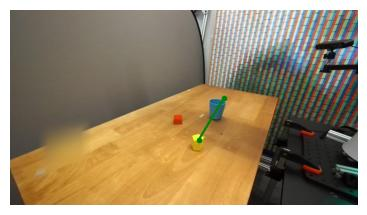
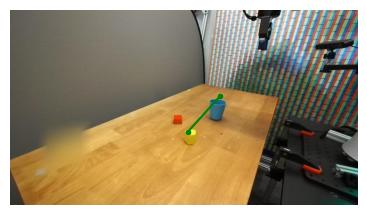
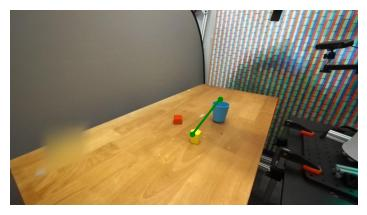

In [8]:
def get_image(images):
    if isinstance(images, (list, tuple)):
        return images[-1]
    else:
        return images
    
def get_depth(images):
    if isinstance(images, (list, tuple)):
        return images[0]
    else:
        return None
    
num_samples = min(3*1, len(test_raw_dataset))
html_imgs = ""
for i in tqdm(range(num_samples)):
    images, sample = test_raw_dataset[i]
    image = get_depth(images) if return_depth else get_image(images)
    html_imgs += render_example(image, label=sample["suffix"], text=sample["prefix"], camera=sample["camera"], 
                                action_encoder_data="xyzrotvec-cam-1024xy", action_encoder_model="xyzrotvec-cam-1024xy")
    
display(HTML(html_imgs))

  0%|          | 0/10 [00:00<?, ?it/s]

text: put the yellow block inside the light blue cup <loc0036><loc0735><loc0049><seg085><seg107><seg040>label: <loc0574><loc0517><loc0062><seg090><seg102><seg037><loc0411><loc0599><loc0074><seg090><seg102><seg037>pred: <loc0574><loc0517><loc0062><seg090><seg102><seg037><loc0411><loc0599><loc0074><seg090><seg102><seg037>,text: put the yellow block inside the light blue cup <loc0161><loc0774><loc0051><seg088><seg108><seg037>label: <loc0634><loc0551><loc0057><seg091><seg098><seg034><loc0444><loc0646><loc0073><seg091><seg098><seg034>pred: <loc0628><loc0557><loc0051><seg052><seg086><seg103><loc0429><loc0637><loc0072><seg052><seg086><seg103>
text: put the yellow block in the cup <loc0331><loc0670><loc0039><seg076><seg103><seg032>label: <loc0571><loc0501><loc0065><seg072><seg114><seg026><loc0402><loc0581><loc0073><seg072><seg114><seg026>pred: <loc0571><loc0501><loc0065><seg072><seg114><seg026><loc0402><loc0581><loc0073><seg072><seg114><seg026>,text: put the yellow block in the cup <loc0026><loc0664><loc0045><seg079><seg104><seg037>label: <loc0626><loc0559><loc0059><seg089><seg102><seg035><loc0415><loc0647><loc0073><seg089><seg102><seg035>pred: <loc0628><loc0152><loc0042><seg057><seg090><seg111><loc0477><loc0550><loc0051><seg057><seg090><seg111>
text: put the yellow block in the blue cup <loc0048><loc0778><loc0053><seg083><seg105><seg027>label: <loc0654><loc0524><loc0055><seg095><seg093><seg032><loc0441><loc0649><loc0070><seg095><seg093><seg032>pred: <loc0654><loc0524><loc0055><seg095><seg093><seg032><loc0441><loc0649><loc0070><seg095><seg093><seg032>,text: put the yellow block in the blue cup <loc0218><loc0786><loc0059><seg080><seg101><seg038>label: <loc0628><loc0480><loc0055><seg095><seg089><seg036><loc0440><loc0571><loc0075><seg095><seg089><seg036>pred: <loc0614><loc0134><loc0051><seg047><seg086><seg097><loc0490><loc0539><loc0066><seg047><seg086><seg097>
text: put the yellow cube inside the blue cup <loc0246><loc0693><loc0052><seg088><seg098><seg036>label: <loc0610><loc0516><loc0060><seg087><seg101><seg027><loc0456><loc0582><loc0071><seg087><seg101><seg027>pred: <loc0610><loc0516><loc0060><seg087><seg101><seg027><loc0456><loc0582><loc0071><seg087><seg101><seg027>,text: put the yellow cube inside the blue cup <loc0085><loc0727><loc0051><seg080><seg111><seg036>label: <loc0671><loc0488><loc0052><seg087><seg100><seg039><loc0393><loc0595><loc0074><seg087><seg100><seg039>pred: <loc0462><loc0584><loc0064><seg046><seg086><seg094><loc0574><loc0134><loc0048><seg046><seg086><seg094>
text: put the yellow block in the cup <loc0162><loc0709><loc0037><seg087><seg108><seg044>label: <loc0645><loc0564><loc0056><seg082><seg108><seg034><loc0442><loc0660><loc0067><seg082><seg108><seg034>pred: <loc0645><loc0564><loc0056><seg082><seg108><seg034><loc0442><loc0660><loc0067><seg082><seg108><seg034>,text: put the yellow block in the cup <loc0055><loc0799><loc0040><seg089><seg107><seg042>label: <loc0566><loc0504><loc0064><seg088><seg101><seg037><loc0411><loc0560><loc0075><seg088><seg101><seg037>pred: <loc0467><loc0522><loc0051><seg057><seg039><seg016><loc0557><loc0134><loc0035><seg057><seg039><seg016>
text: place the yellow block inside the light blue cup <loc0034><loc0875><loc0053><seg084><seg105><seg027>label: <loc0642><loc0537><loc0057><seg093><seg096><seg042><loc0434><loc0629><loc0072><seg093><seg096><seg042>pred: <loc0642><loc0537><loc0057><seg093><seg096><seg042><loc0434><loc0629><loc0072><seg093><seg096><seg042>,text: place the yellow block inside the light blue cup <loc0098><loc0741><loc0062><seg091><seg105><seg041>label: <loc0636><loc0494><loc0054><seg103><seg082><seg045><loc0447><loc0664><loc0072><seg103><seg082><seg045>pred: <loc0656><loc0481><loc0055><seg057><seg087><seg111><loc0545><loc0134><loc0051><seg057><seg087><seg111>
text: put the yellow block into the blue cup <loc0283><loc0712><loc0059><seg085><seg103><seg039>label: <loc0590><loc0508><loc0064><seg092><seg094><seg040><loc0441><loc0571><loc0073><seg092><seg094><seg040>pred: <loc0590><loc05
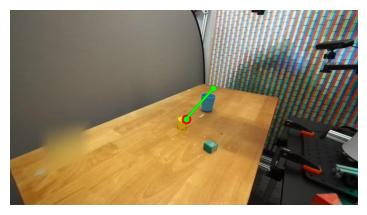
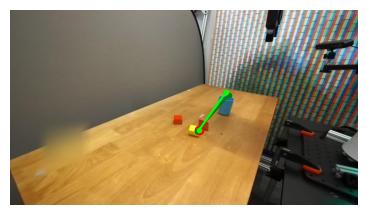
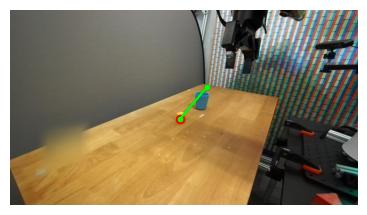
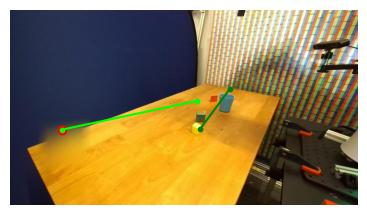
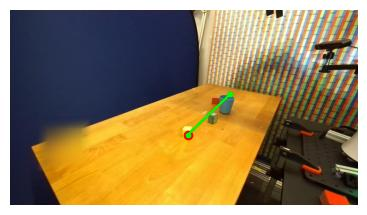
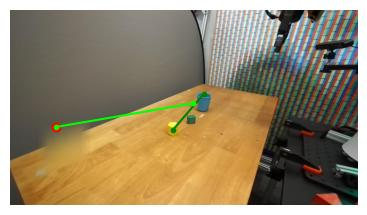
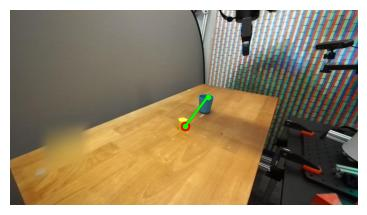
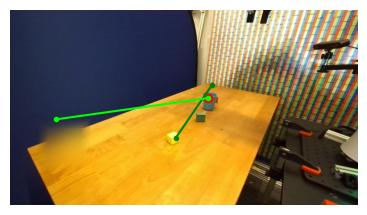
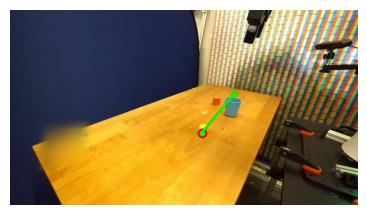
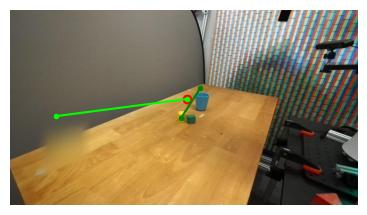
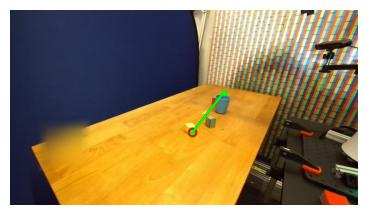
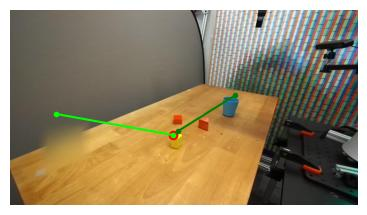
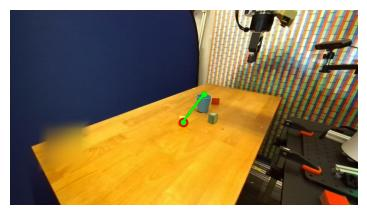
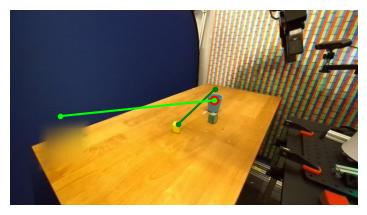
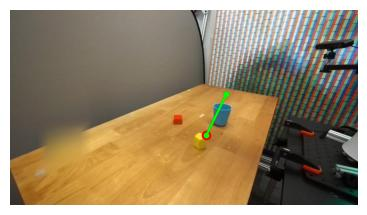
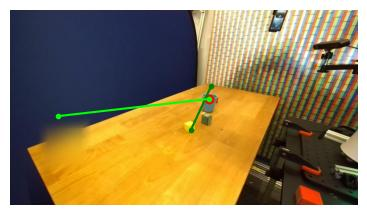
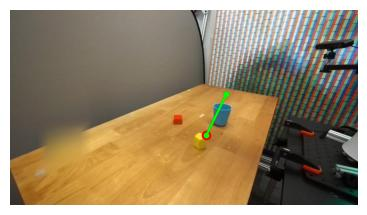
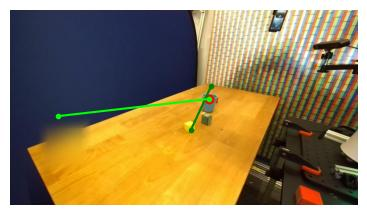
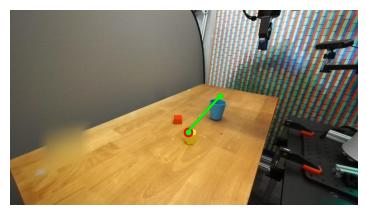
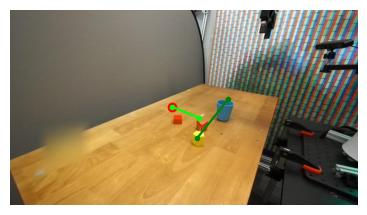
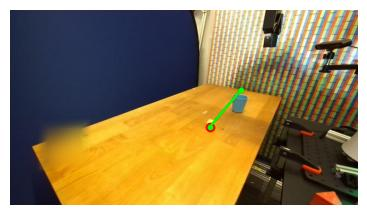
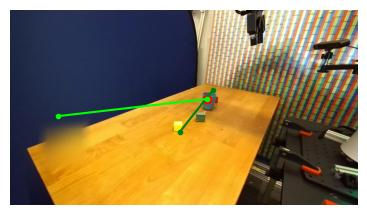
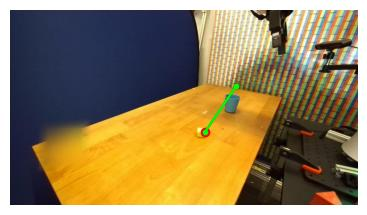
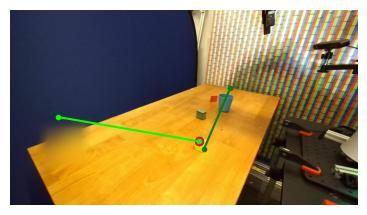
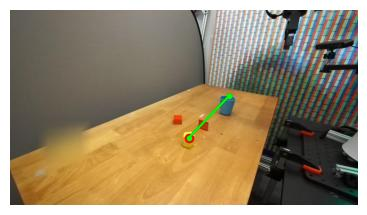
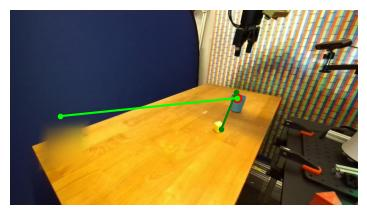
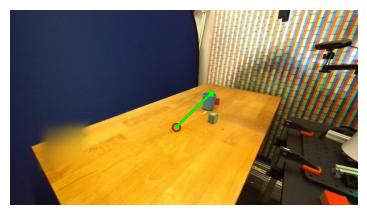
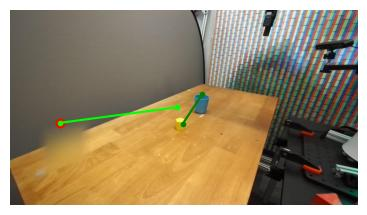
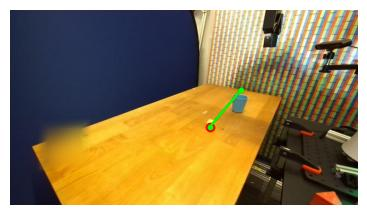
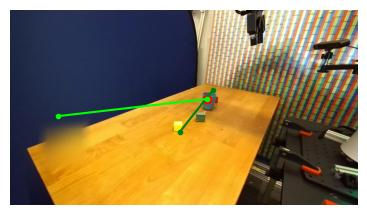
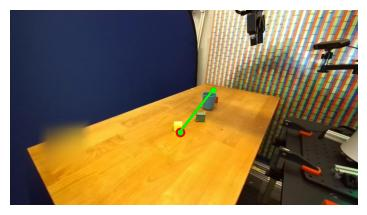
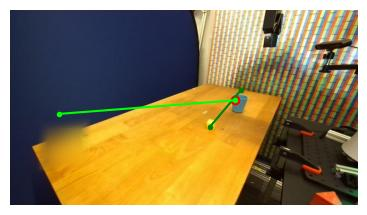
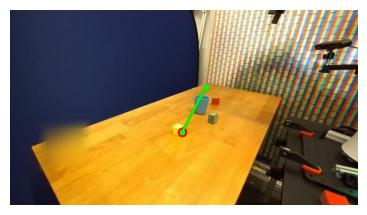
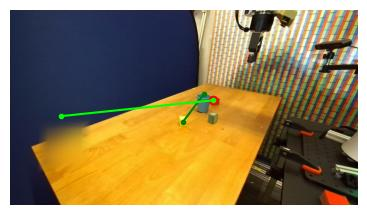
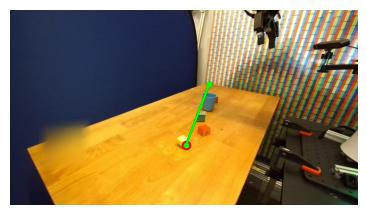
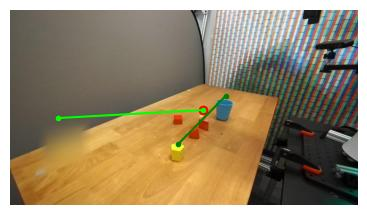
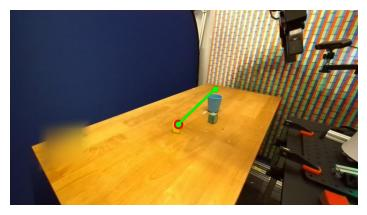
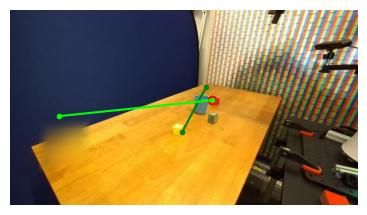
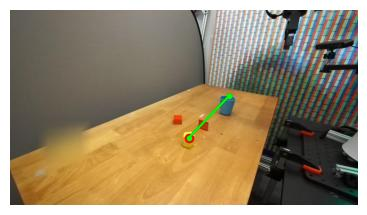
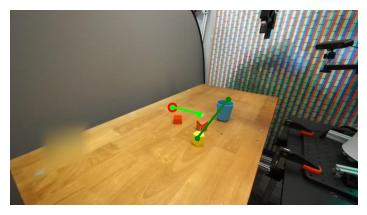
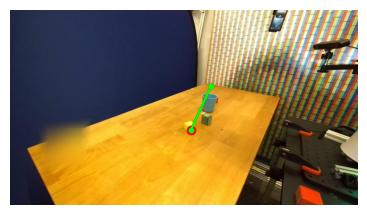
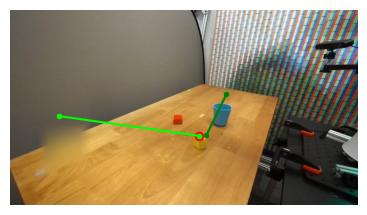
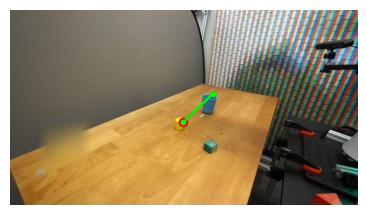
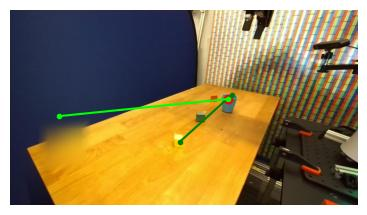
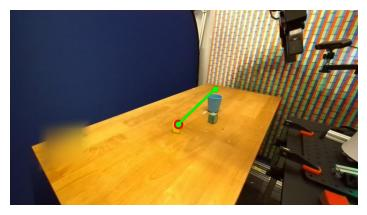
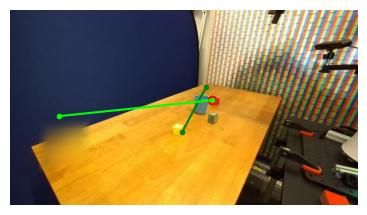
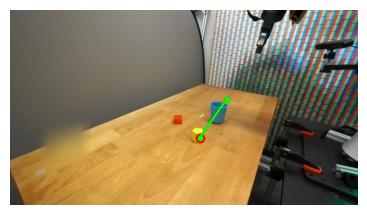
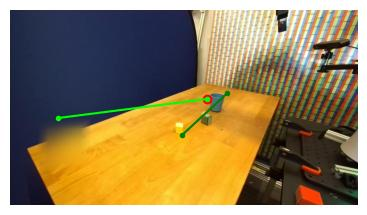
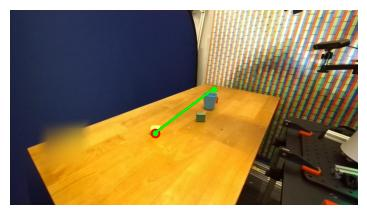
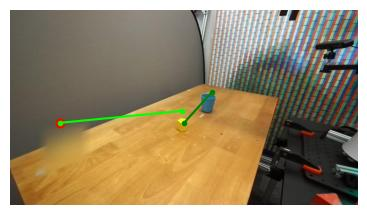
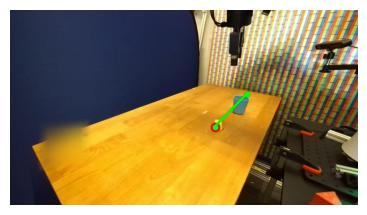
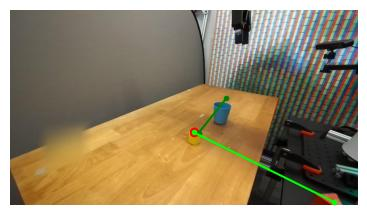
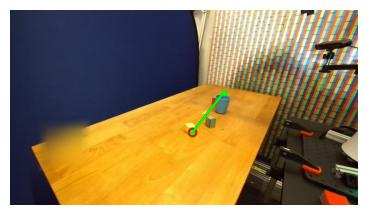
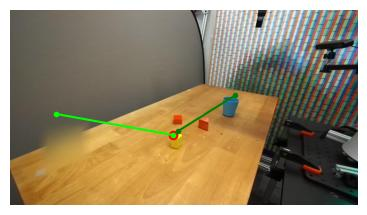
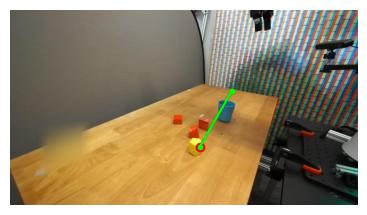
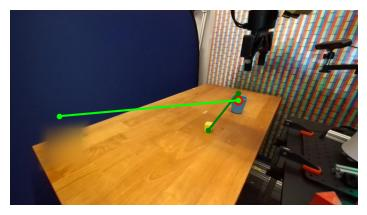
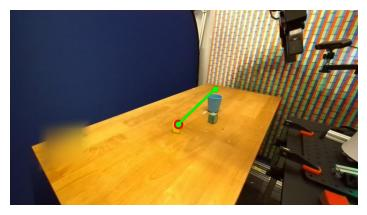
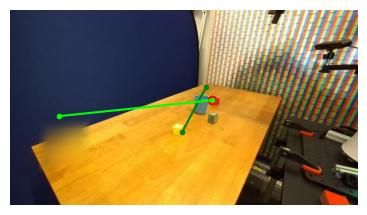
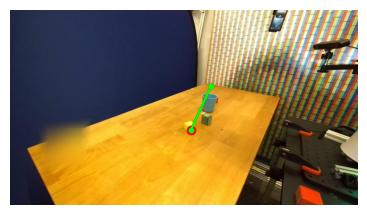
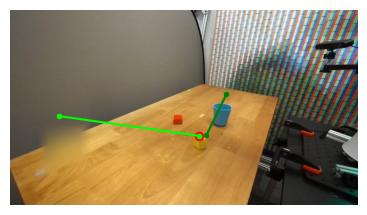
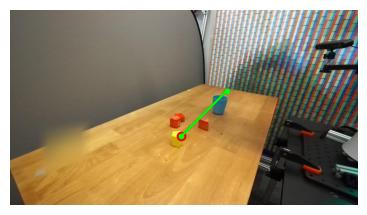
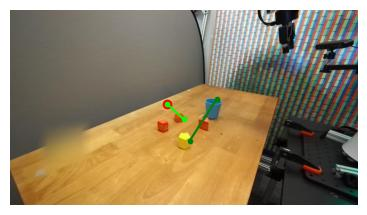
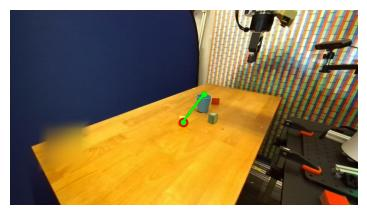
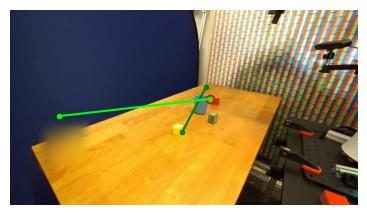
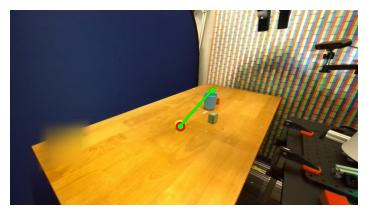
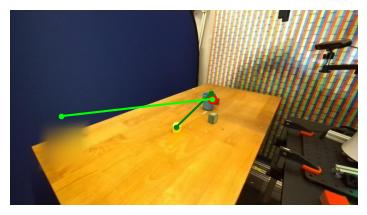
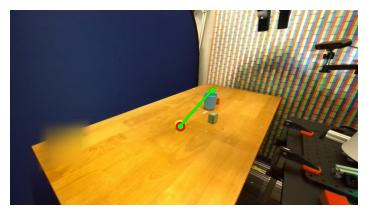
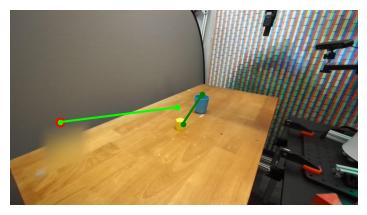
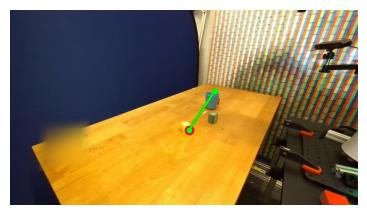
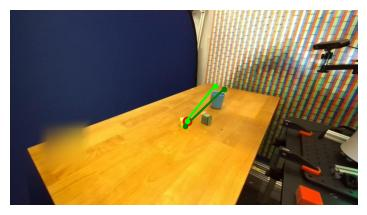
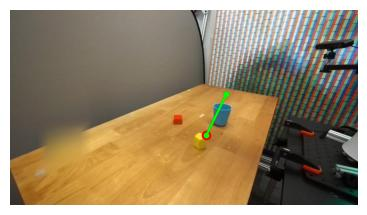
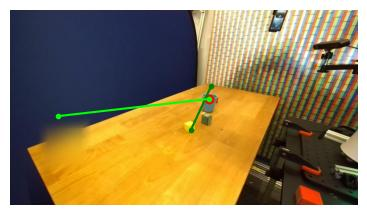
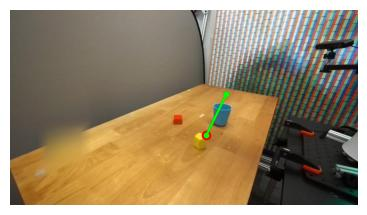
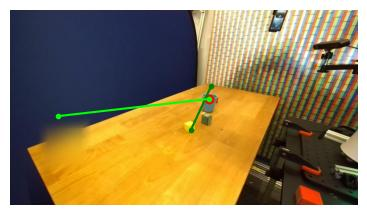
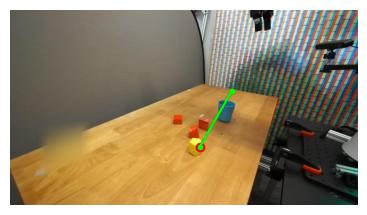
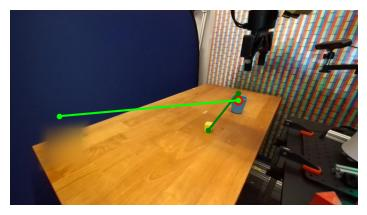
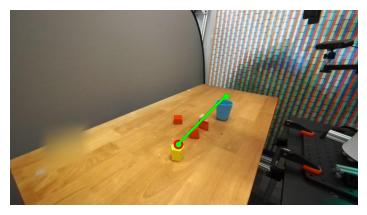
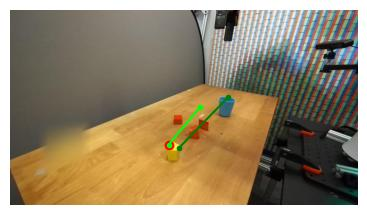
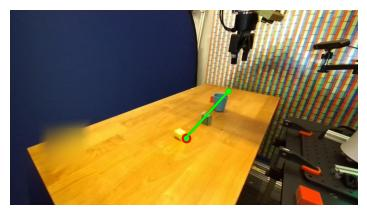
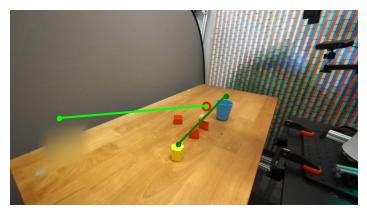
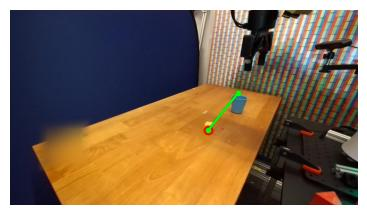
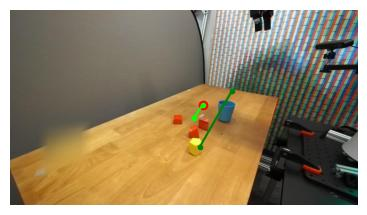
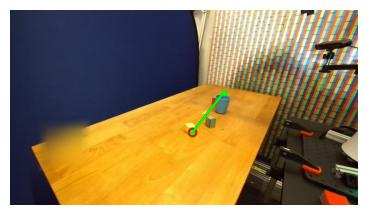
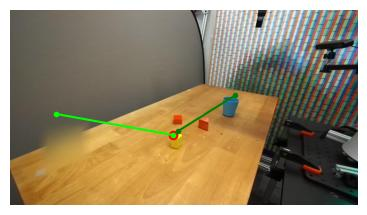
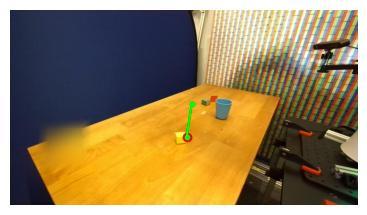
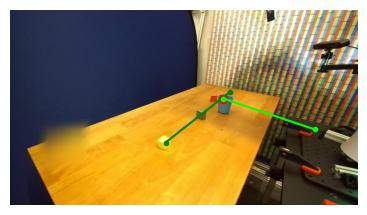
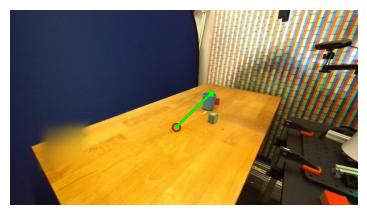
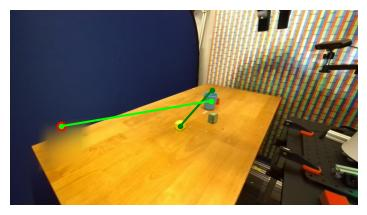
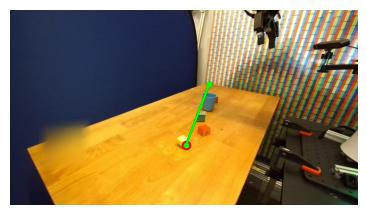
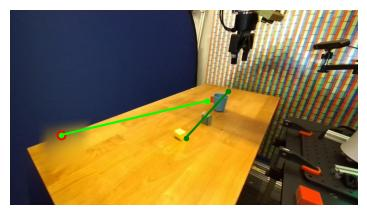
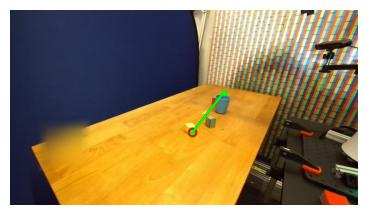
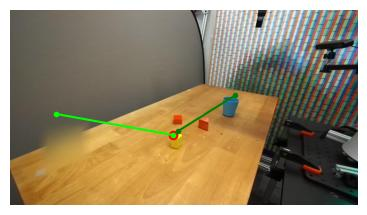
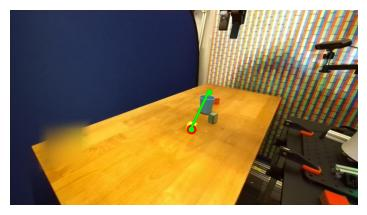
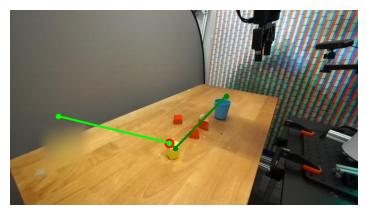
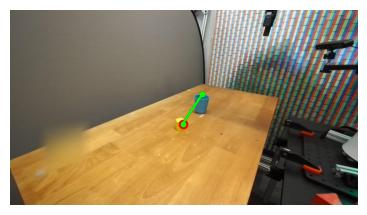
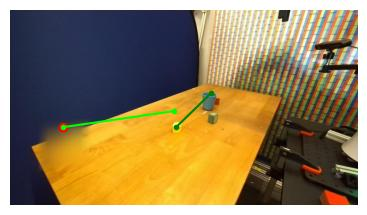
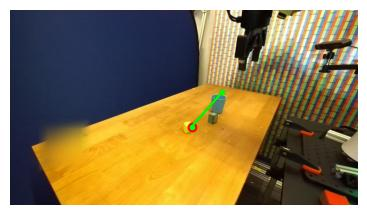
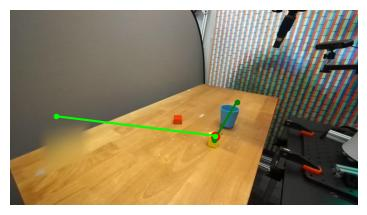
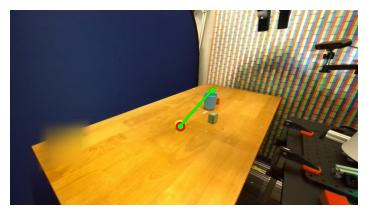
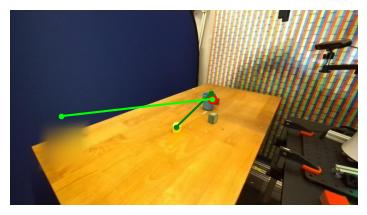
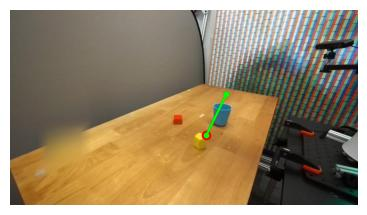
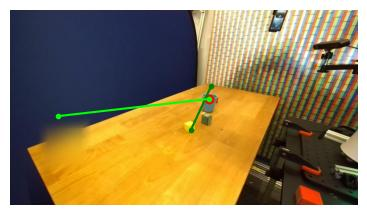
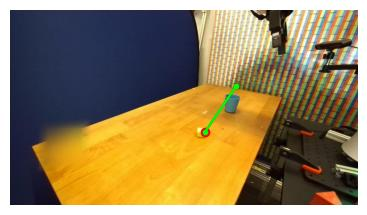
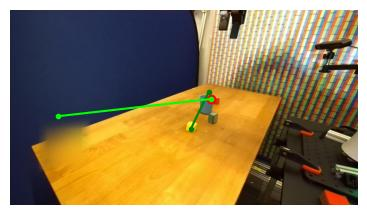
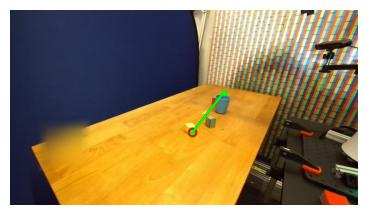
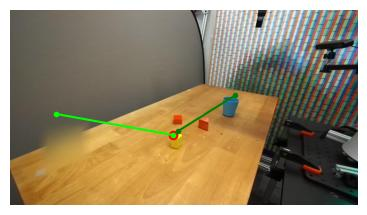
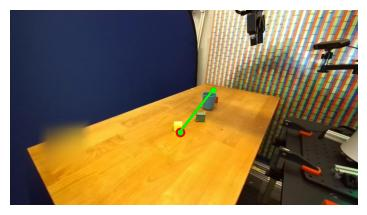
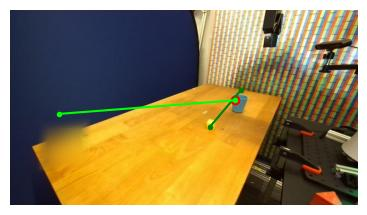
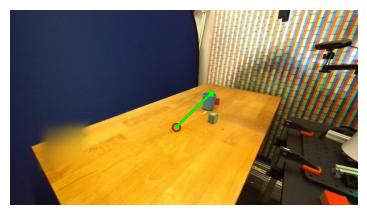
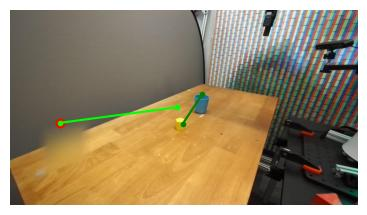
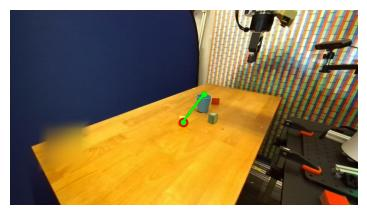
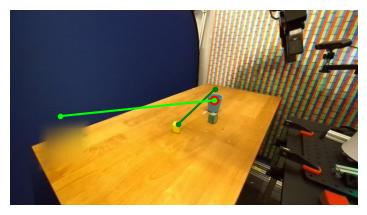
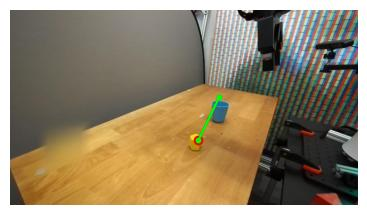
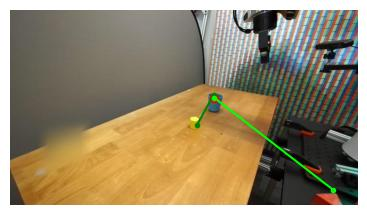
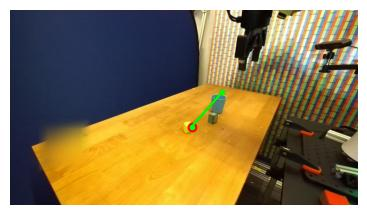
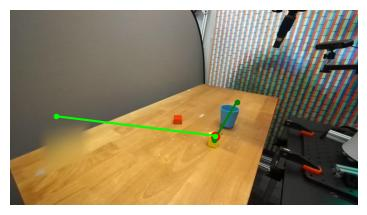
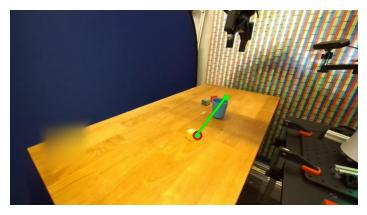
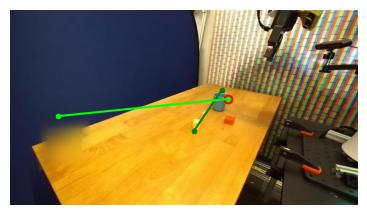
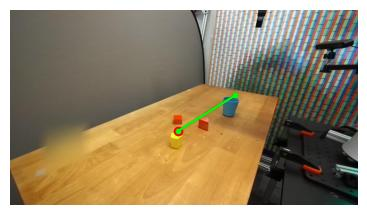
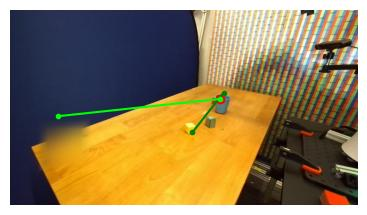
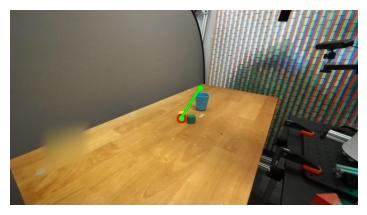
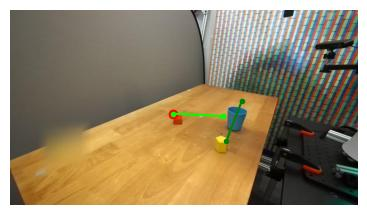
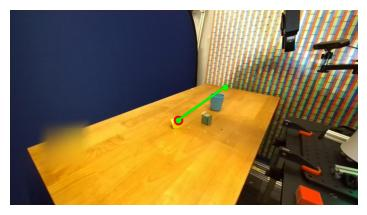
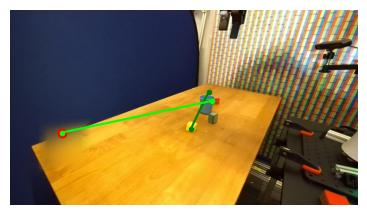
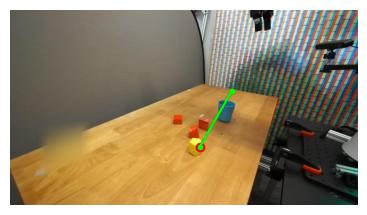
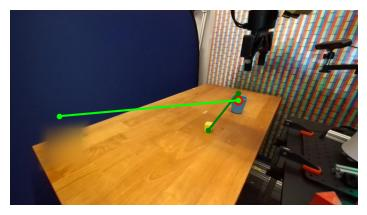
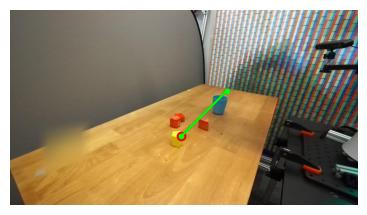
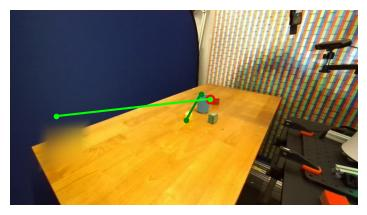
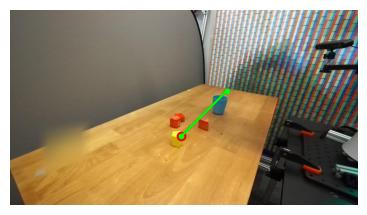
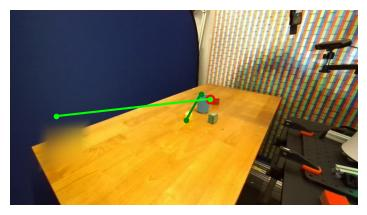
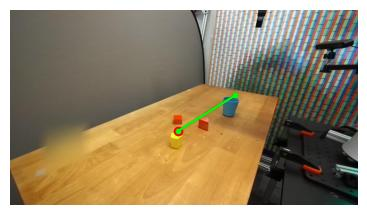
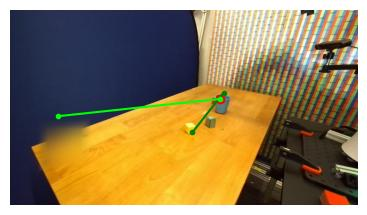
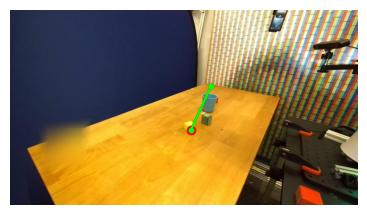
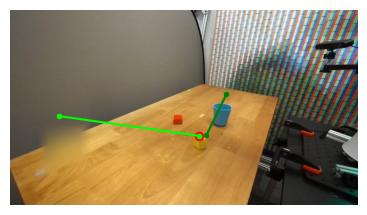
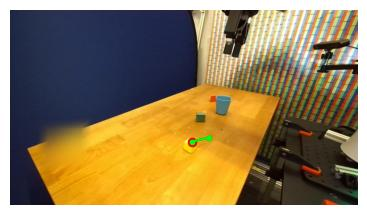
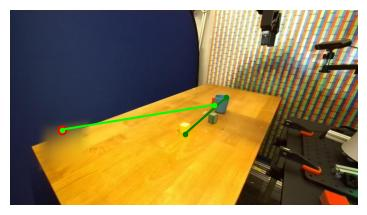
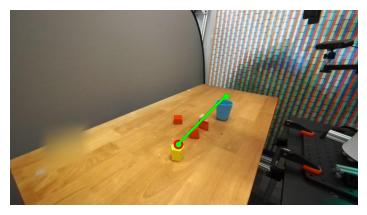
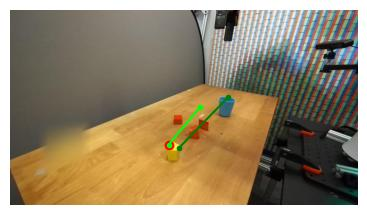
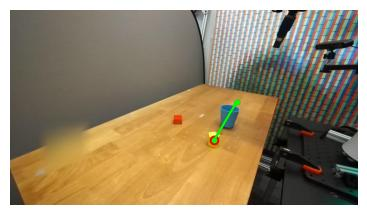
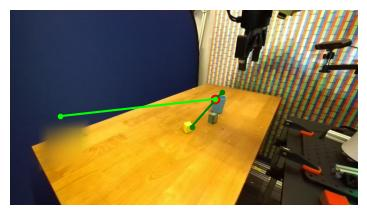
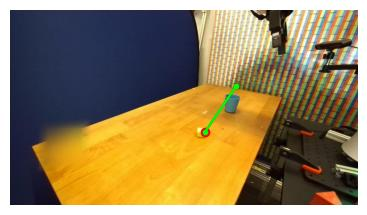
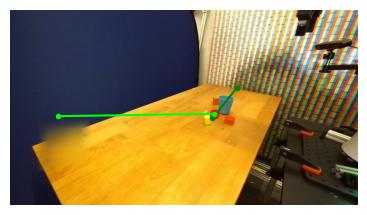
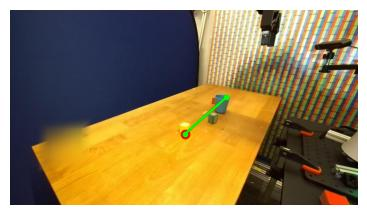
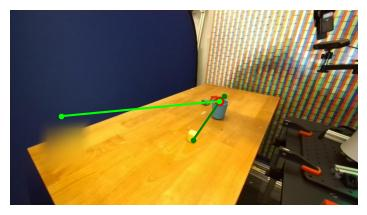
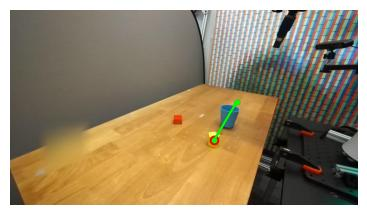
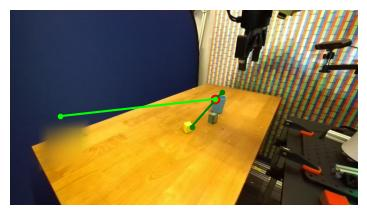
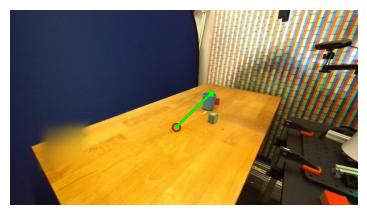
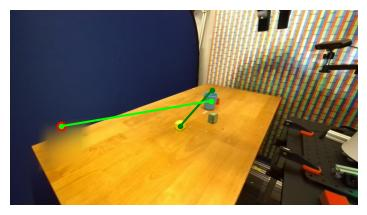
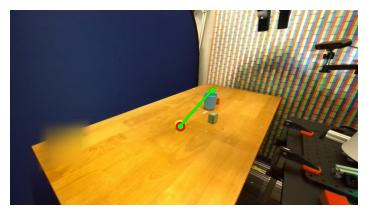
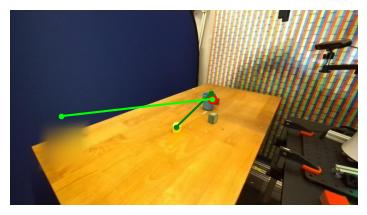
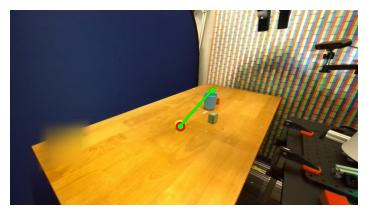
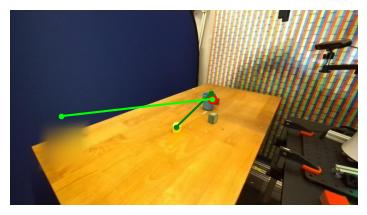
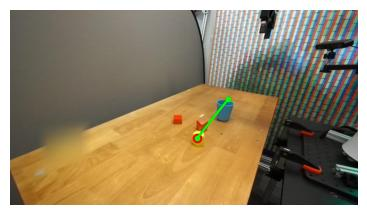
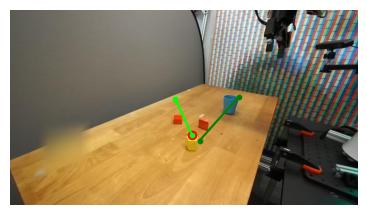
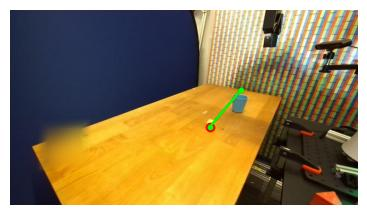
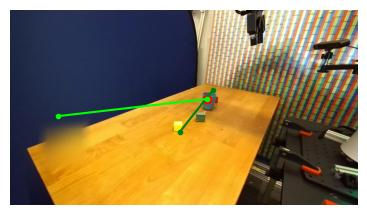
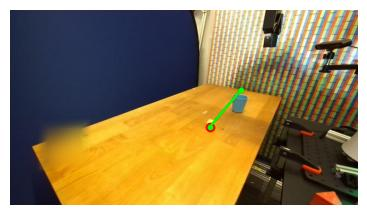
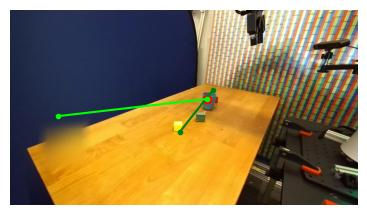
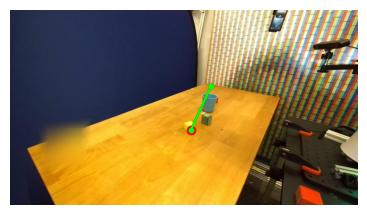
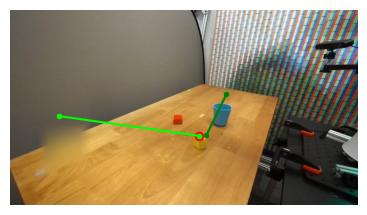

done
HTML file saved for CLEVR.


In [9]:
eval_batch_size = 8
test_samples = 80 # len(test_dataset)
pred_list = []
#html_imgs = ""
html_imgs = "<table style='width:100%; border-collapse: collapse;'>"


for start_idx in tqdm(range(0, test_samples, eval_batch_size), total=ceil(test_samples / eval_batch_size)):
    batch = [test_dataset[i] for i in range(start_idx, min(start_idx + eval_batch_size, test_samples))]
    inputs = collate_fn(batch)
    prefix_length = inputs["input_ids"].shape[-1]    
    decoded = []

    with torch.inference_mode():
        generation = model.generate(**inputs, max_new_tokens=max_tokens, do_sample=False, use_cache=False)
        # show only those images whose suffix is 12 tokens
        good_generation = generation[:, prefix_length:].shape[-1] == max_tokens
        for i in range(len(generation)):
            #if generation[i, prefix_length:].shape[-1] != max_tokens:
            #    decoded.append("")
            #else:
            decoded.append(processor.decode(generation[i, prefix_length:], skip_special_tokens=True))
        
        # decoded = [processor.decode(x, skip_special_tokens=True) for x in generation[:, prefix_length:]]
    pred_list.extend(decoded)
    
    for batch_entry, decoded_str in zip(batch, decoded):
        if return_depth:
            (depth, image), sample = batch_entry
        else:
            images, samples = batch_entry
        extra_text = ""
        # check if valid
        is_valid = check_if_valid(decoded_str, samples[1]["suffix"])
        if not is_valid:
            print(f"Invalid prediction: {decoded_str} with gt {samples[1]['suffix']}")
            extra_text = " NOT_VALID"

        #if decoded_str == "":
        #    continue
        html_img = render_example(images[0], text=samples[0]["prefix"], label=samples[0]["suffix"], prediction=samples[0]["suffix"], camera=sample["camera"], 
                                  action_encoder_data="xyzrotvec-cam-1024xy", action_encoder_model="xyzrotvec-cam-1024xy")
        # html_imgs += html_img
        html_query = render_example(images[1], text=samples[1]["prefix"]+extra_text, label=samples[1]["suffix"], prediction=decoded_str, camera=sample["camera"], 
                                    action_encoder_data="xyzrotvec-cam-1024xy", action_encoder_model=action_encoder)
        # html_imgs += html_query
        # html_imgs += "\n"

        html_imgs += "<tr>"
        html_imgs += f"<td style='width:33%; '>{html_img}</td>"
        html_imgs += f"<td style='width:33%; '>{html_query}</td>"
        html_imgs += "</tr>"

html_imgs += "</table>"
plot_images = True
if plot_images:
    from IPython.display import display, HTML
    display(HTML(html_imgs))

print("done")


# Save the HTML to a file after generating it
with open(html_save_file_clevr, "w") as f:
    f.write(html_imgs)
print("HTML file saved for CLEVR.")

# Training data

In [14]:
# LOAD TRAINING DATA AND TEST THERE
# if /tmp/indoorCVPR and /tmp/clevr-act-7-depth do not exist, transfer them from the shared folder
if not os.path.exists('/tmp/indoorCVPR') or not os.path.exists('/tmp/clevr-act-7-depth'):
    !rsync -a --progress /data/lmbraid19/argusm/datasets/indoorCVPR.tar /tmp/ && mkdir -p /tmp/indoorCVPR && tar -xf /tmp/indoorCVPR.tar -C /tmp/indoorCVPR
    !rsync -a --progress /data/lmbraid19/argusm/datasets/clevr-act-7-depth /tmp/
    !file /tmp/indoorCVPR
    !file /tmp/clevr-act-7-depth
else:
    print('Data already exists')

Data already exists


Loading pre-sampled pairs from /data/lmbraid21/bratulic/max_pali/datasets/train_dataset__img_1_pr_interleaved_enc_xyzrotvec-cam-1024xy_new.pkl
Creating presampled pairs for validation/test set.
Statistics about the paired dataset:
Total number of images (across tasks): 1000
dataset_location: /tmp/clevr-act-7-depth samples: 150000 paired_samples: 1000



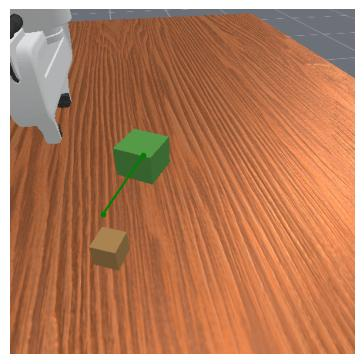
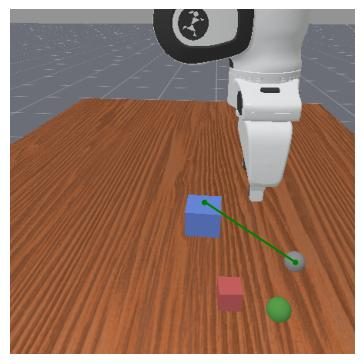
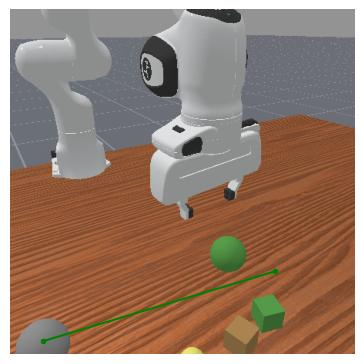
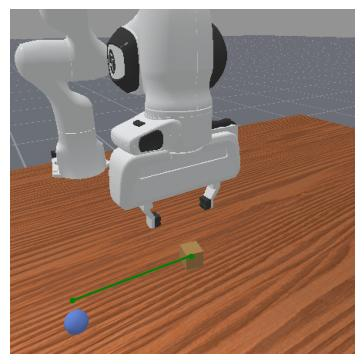
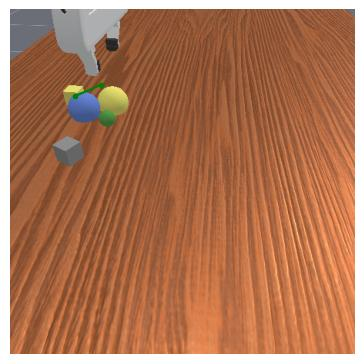
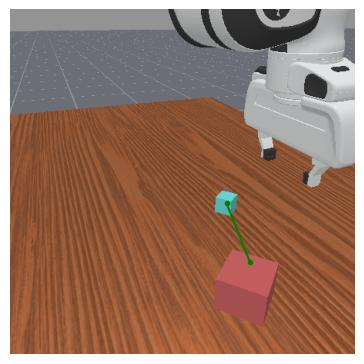

In [10]:
from data_loader_h5 import H5Dataset
from data_augmentations import augment_image_rgb, RandomizeBackgrounds
from data_augmentations import complexify_text, DepthAugmentation
from data_loader_images import ImageFolderDataset
from utils_vis import render_example
from torchvision import transforms

dataset_location = Path("/tmp/clevr-act-7-depth")

num_images_in_context = 1
image_order = "interleaved"
run_name = f"_imagesInContext_{num_images_in_context}_promptOrder_{image_order}"
#load_presampled_pairs_path = Path("/data/lmbraid21/bratulic/max_pali/datasets") / f"train_dataset_{run_name}_new.pkl"
bg_image_dataset = ImageFolderDataset("/tmp/indoorCVPR/Images", transform=transforms.RandomResizedCrop((448,448)))
randomize_background = RandomizeBackgrounds(p=0.0, background_images=bg_image_dataset)
augment_depth = DepthAugmentation(depth_range=(25, 100), max_delta_depth=35)
raw_dataset = H5Dataset(dataset_location, augment_rgbds=randomize_background, augment_rgb=None, augment_text=None,
                          augment_depth=None, return_depth=False, action_encoder=action_encoder)

run_name = f"_img_{num_images_in_context}_pr_{image_order}_enc_{action_encoder}"
load_presampled_pairs_path = Path("/data/lmbraid21/bratulic/max_pali/datasets") / f"train_dataset_{run_name}_new.pkl"
presampled_eval_sequences_path = Path("/data/lmbraid21/bratulic/max_pali/datasets") / f"train_dataset_{run_name}_pCopy0_pSorting1.0_sortBYtrajectory_shape_presampled_eval_sequences.pkl"
    

train_dataset = PairedDataset(raw_dataset, num_images_in_context=num_images_in_context, image_order=image_order, load_presampled_pairs_path=load_presampled_pairs_path, plot_statistics=False,
                              p_copy=0.0, p_sort_by_l2_distance=1.0, presampled_path=presampled_eval_sequences_path, mode="test", sort_criteria="trajectory_shape")

print("dataset_location:", dataset_location,"samples:", len(raw_dataset), "paired_samples:", len(train_dataset))

num_samples = 3*2
html_imgs = ""
for i in range(num_samples):
    image, sample = raw_dataset[i]
    prefix = sample["prefix"]
    html_imgs += render_example(image, label=sample["suffix"], text=prefix, camera=sample["camera"], 
                                action_encoder_model=action_encoder, action_encoder_data=action_encoder)

plot_images = True
if plot_images:
    from IPython.display import display, HTML
    display(HTML(html_imgs))

  0%|          | 0/10 [00:00<?, ?it/s]

text: move small red sphere onto small brown cube <loc0527><loc0209><loc0044><seg045><seg081><seg090>label: <loc0796><loc0334><loc0049><seg045><seg081><seg090><loc0567><loc0466><loc0064><seg045><seg081><seg090>pred: <loc0796><loc0334><loc0049><seg045><seg081><seg090><loc0567><loc0466><loc0064><seg045><seg081><seg090>,text: move small red sphere onto small brown cube <loc0541><loc0307><loc0038><seg044><seg079><seg087>label: <loc0873><loc0098><loc0041><seg044><seg079><seg087><loc0602><loc0478><loc0055><seg044><seg079><seg087>pred: <loc0636><loc0476><loc0063><seg044><seg079><seg087><loc0759><loc0056><loc0045><seg044><seg079><seg087>
text: move small gray sphere onto large gray sphere <loc0273><loc0223><loc0045><seg063><seg087><seg122>label: <loc0639><loc0433><loc0050><seg063><seg087><seg122><loc0258><loc0478><loc0061><seg063><seg087><seg122>pred: <loc0639><loc0433><loc0050><seg063><seg087><seg122><loc0258><loc0478><loc0061><seg063><seg087><seg122>,text: move small gray sphere onto large gray sphere <loc0374><loc0092><loc0039><seg061><seg086><seg116>label: <loc0524><loc0334><loc0054><seg061><seg086><seg116><loc0231><loc0301><loc0063><seg061><seg086><seg116>pred: <loc0276><loc0310><loc0069><seg061><seg086><seg116><loc0376><loc0312><loc0051><seg061><seg086><seg116>
text: move small purple cube onto large red sphere <loc0518><loc0276><loc0043><seg042><seg080><seg085>label: <loc0641><loc0465><loc0066><seg039><seg070><seg073><loc0578><loc0379><loc0060><seg039><seg070><seg073>pred: <loc0641><loc0465><loc0066><seg039><seg070><seg073><loc0578><loc0379><loc0060><seg039><seg070><seg073>,text: move small purple cube onto large red sphere <loc0511><loc0277><loc0043><seg042><seg078><seg083>label: <loc0651><loc0416><loc0064><seg039><seg069><seg072><loc0650><loc0160><loc0050><seg039><seg069><seg072>pred: <loc0607><loc0409><loc0066><seg039><seg069><seg072><loc0583><loc0152><loc0057><seg039><seg069><seg072>
text: move small blue cube onto small cyan cube <loc0559><loc0722><loc0044><seg042><seg065><seg067>label: <loc0676><loc0749><loc0060><seg042><seg058><seg055><loc0528><loc0569><loc0069><seg042><seg058><seg055>pred: <loc0676><loc0749><loc0060><seg042><seg058><seg055><loc0528><loc0569><loc0069><seg042><seg058><seg055>,text: move small blue cube onto small cyan cube <loc0633><loc0797><loc0048><seg042><seg065><seg065>label: <loc0652><loc0640><loc0071><seg042><seg059><seg056><loc0612><loc0732><loc0069><seg042><seg059><seg056>pred: <loc0628><loc0644><loc0068><seg042><seg059><seg056><loc0567><loc0723><loc0070><seg042><seg059><seg056>
text: move large cyan sphere onto small gray cube <loc0264><loc0296><loc0049><seg062><seg034><seg010>label: <loc0553><loc0280><loc0052><seg062><seg034><seg010><loc0509><loc0226><loc0043><seg062><seg034><seg010>pred: <loc0553><loc0280><loc0052><seg062><seg034><seg010><loc0509><loc0226><loc0043><seg062><seg034><seg010>,text: move large cyan sphere onto small gray cube <loc0310><loc0349><loc0052><seg058><seg030><seg015>label: <loc0832><loc0291><loc0034><seg058><seg030><seg015><loc0510><loc0486><loc0053><seg058><seg030><seg015>pred: <loc0800><loc0287><loc0037><seg058><seg030><seg015><loc0477><loc0484><loc0056><seg058><seg030><seg015>
text: move small green cube onto large yellow cube <loc0591><loc0458><loc0047><seg044><seg073><seg079>label: <loc0794><loc0613><loc0054><seg043><seg071><seg077><loc0904><loc0008><loc0040><seg043><seg071><seg077>pred: <loc0794><loc0613><loc0054><seg043><seg071><seg077><loc0904><loc0008><loc0040><seg043><seg071><seg077>,text: move small green cube onto large yellow cube <loc0667><loc0389><loc0045><seg044><seg073><seg081>label: <loc0697><loc0628><loc0064><seg044><seg075><seg082><loc0935><loc0388><loc0044><seg044><seg075><seg082>pred: <loc0939><loc0381><loc0042><seg044><seg075><seg082><loc0576><loc0636><loc0061><seg044><seg075><seg082>
text: move large blue sphere onto large cyan sphere <loc0573><loc0631><loc0048><seg041><seg068><seg070>label: <loc0701><loc0792><loc0063><seg041><seg068><seg070><loc089
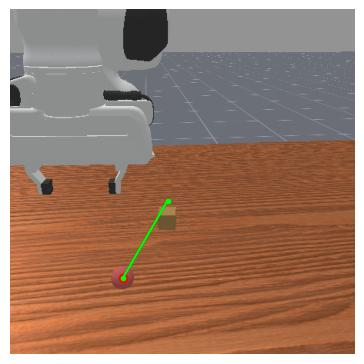
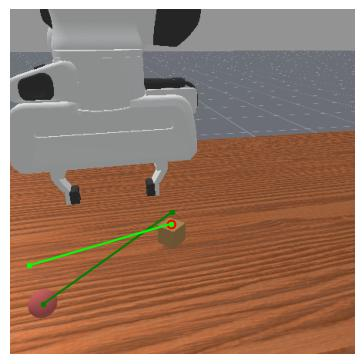
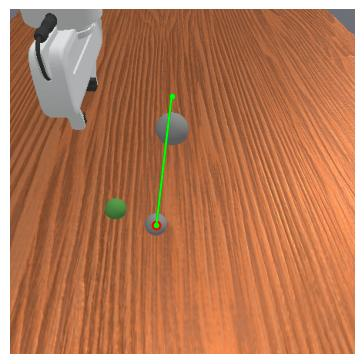
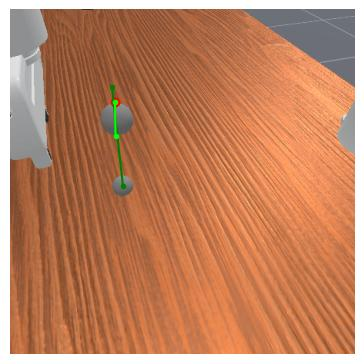
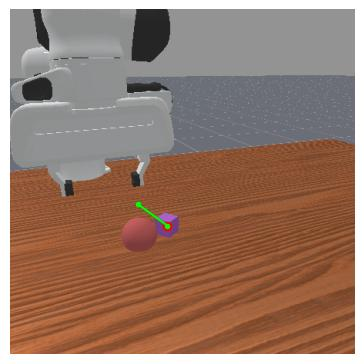
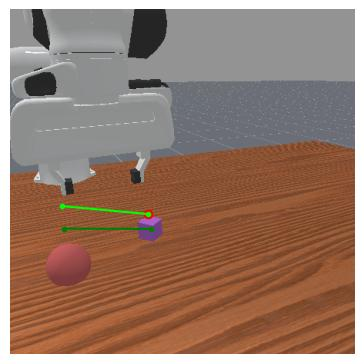
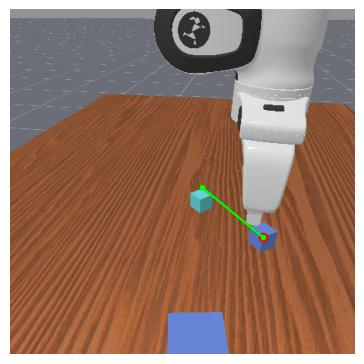
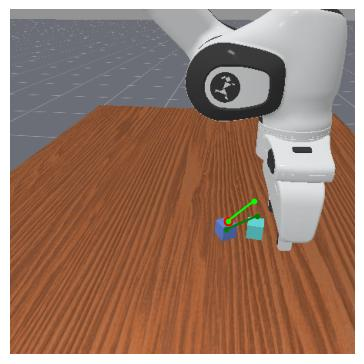
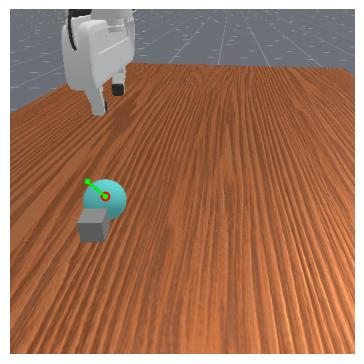
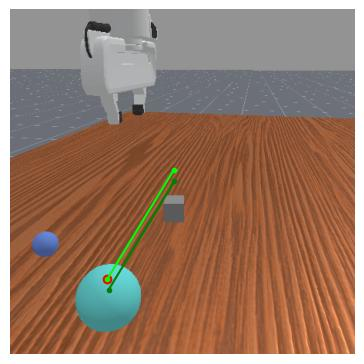
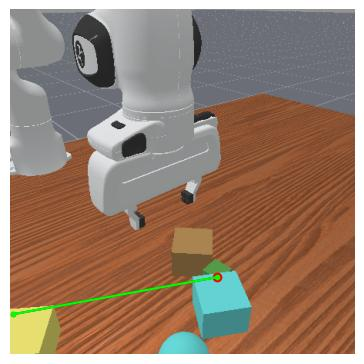
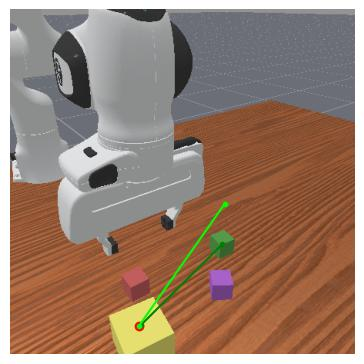
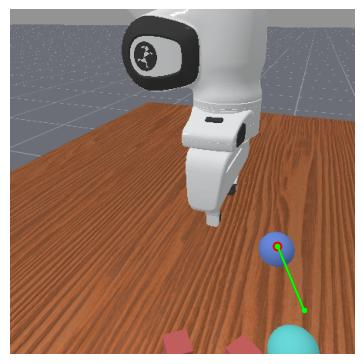
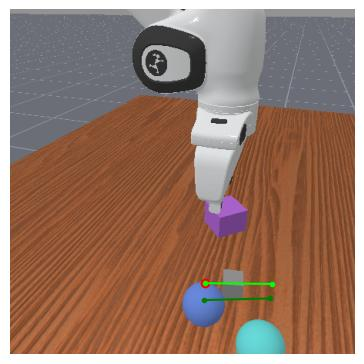
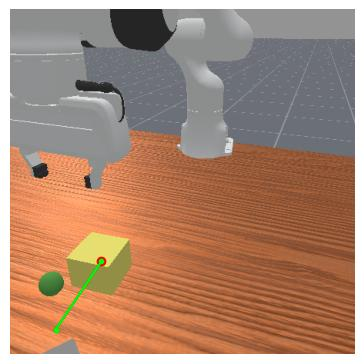
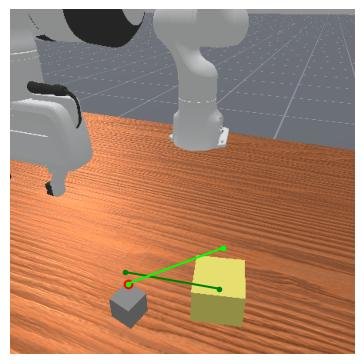
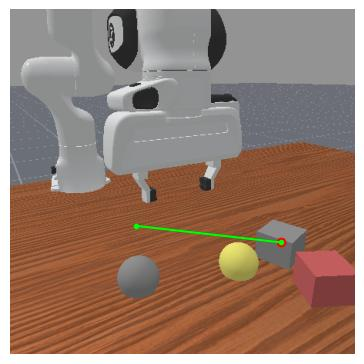
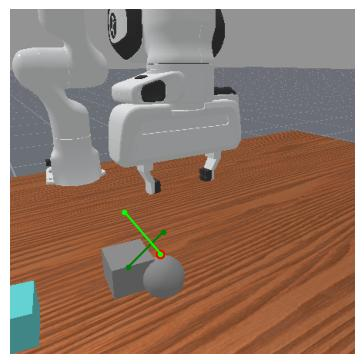
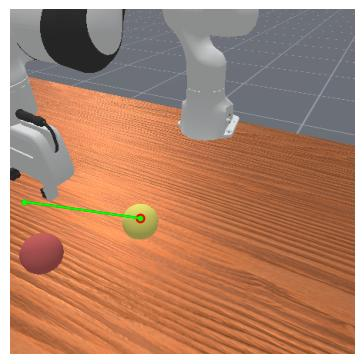
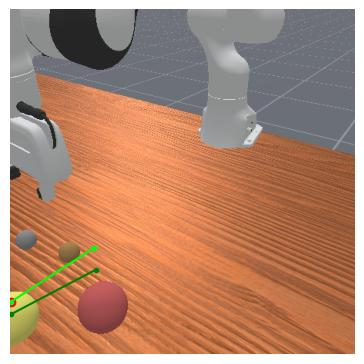
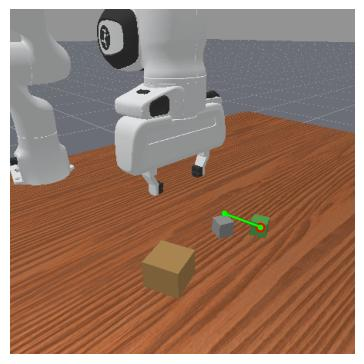
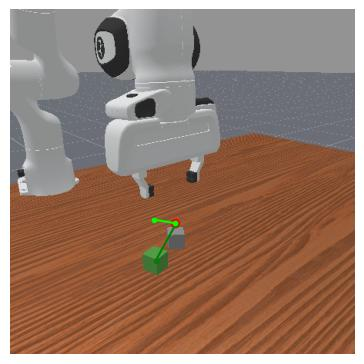
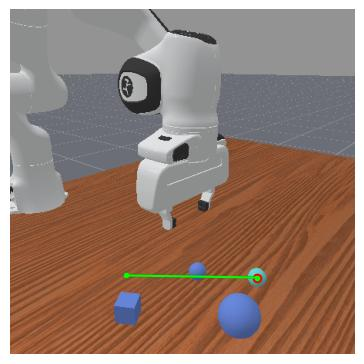
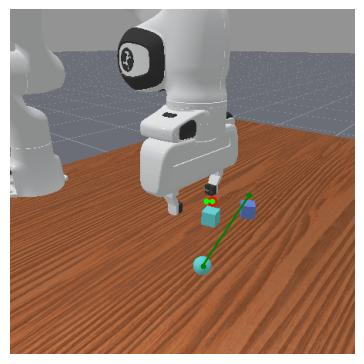
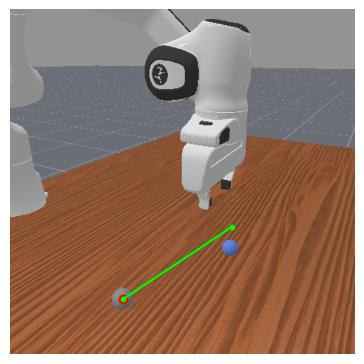
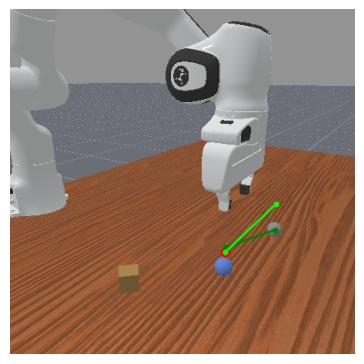
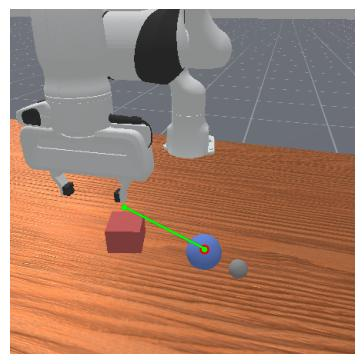
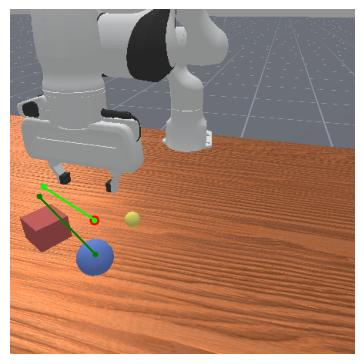
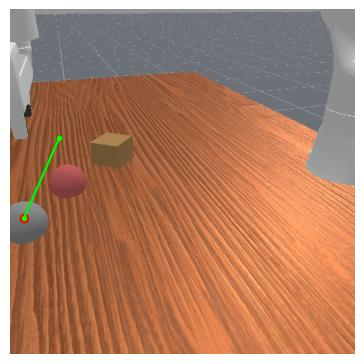
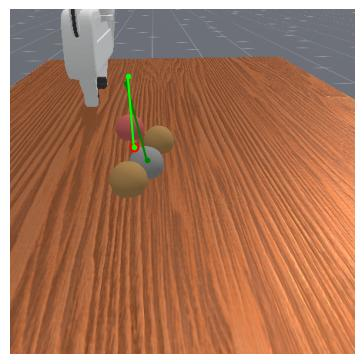
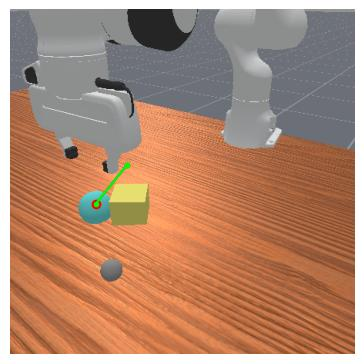
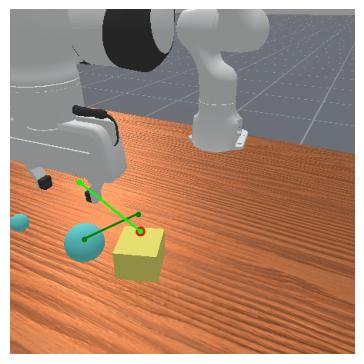
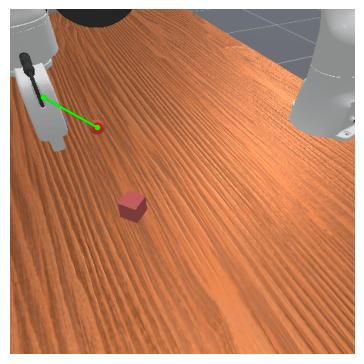
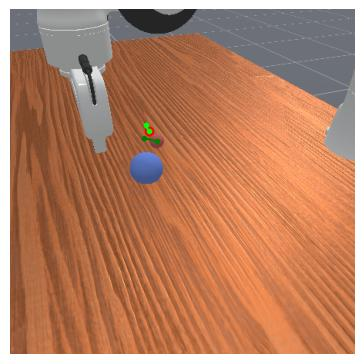
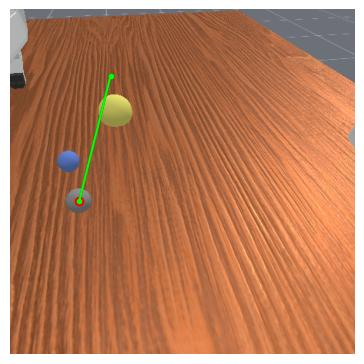
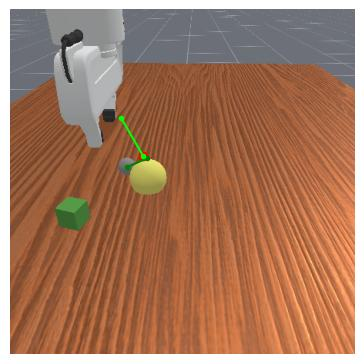
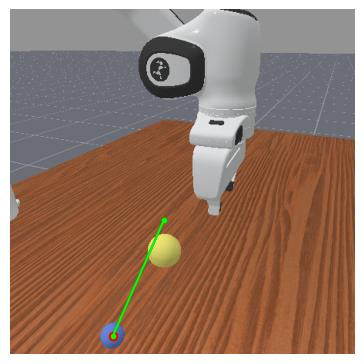
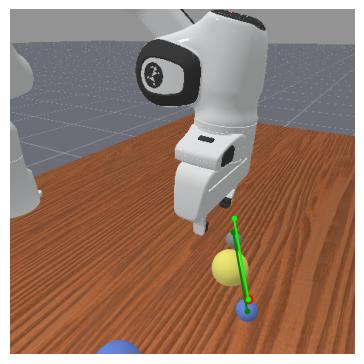
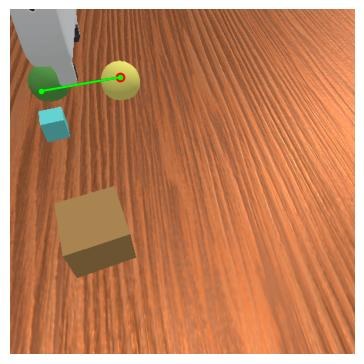
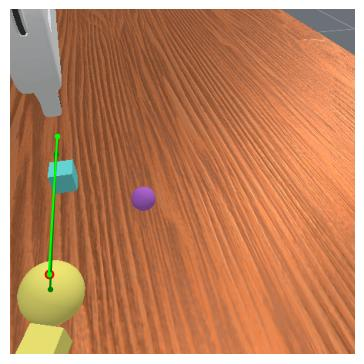
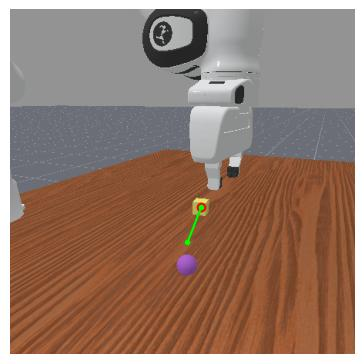
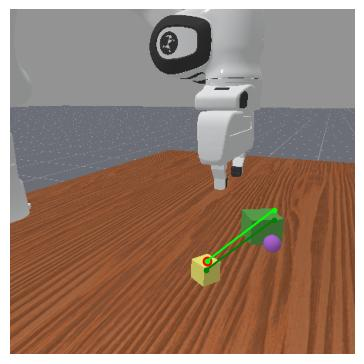
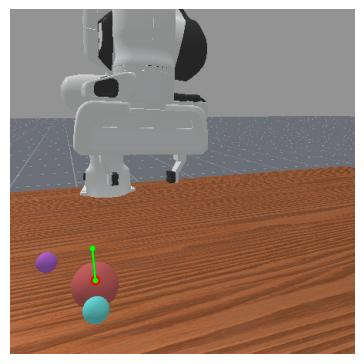
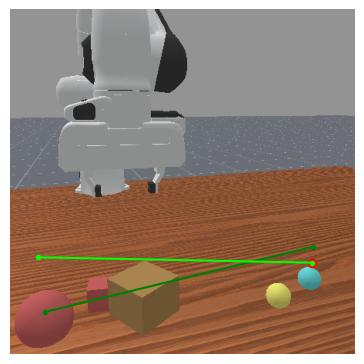
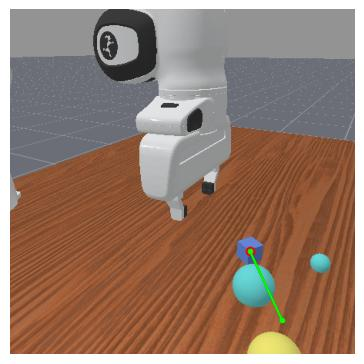
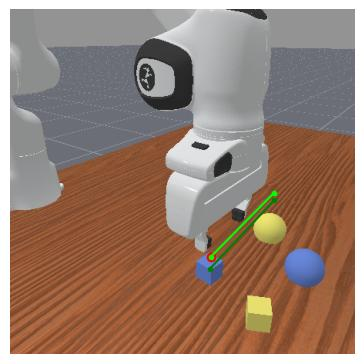
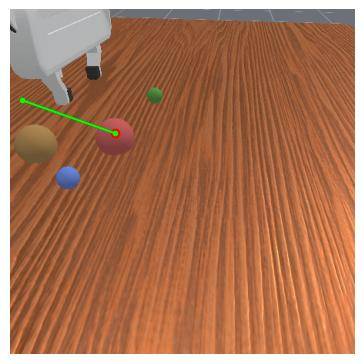
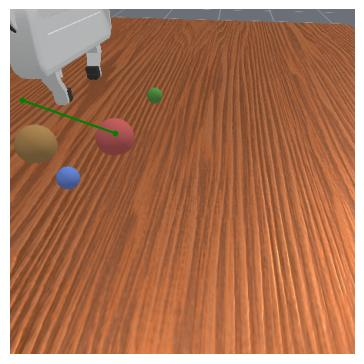
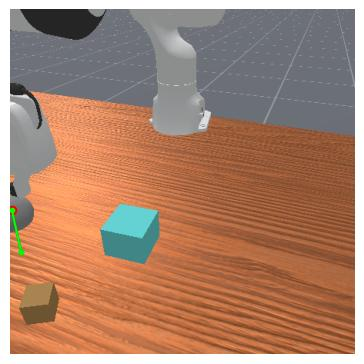
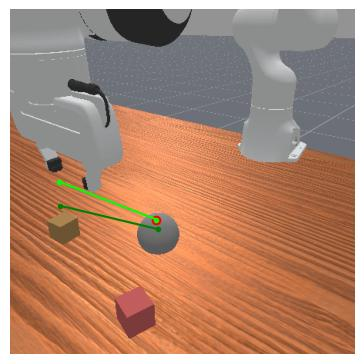
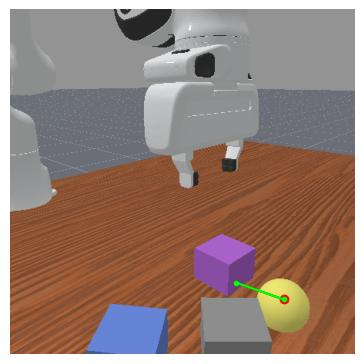
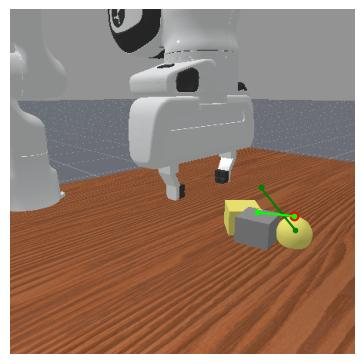
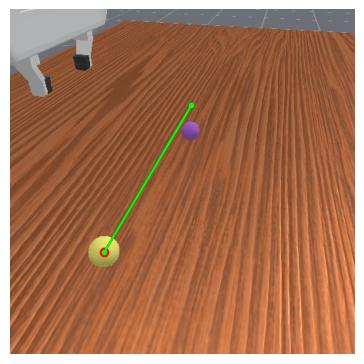
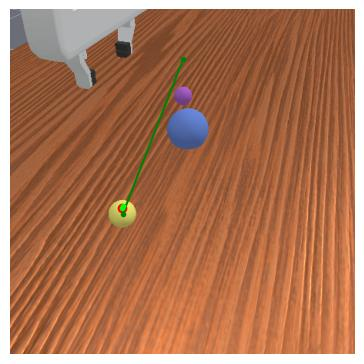
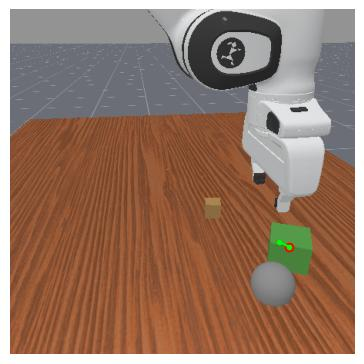
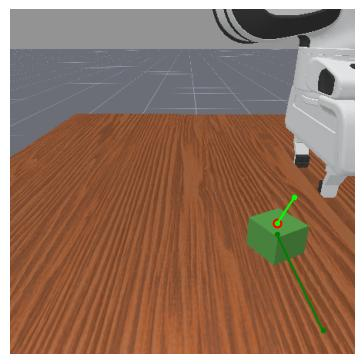
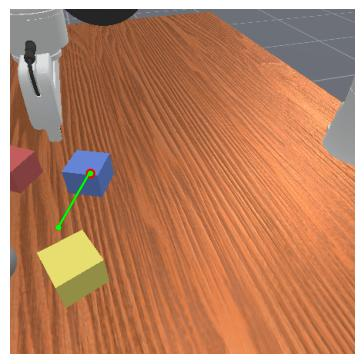
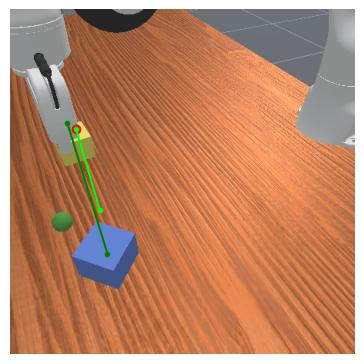
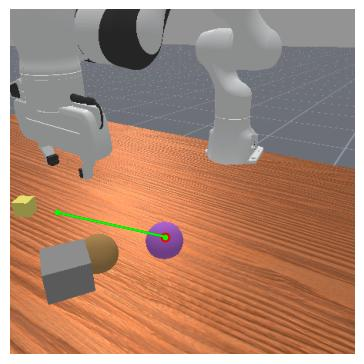
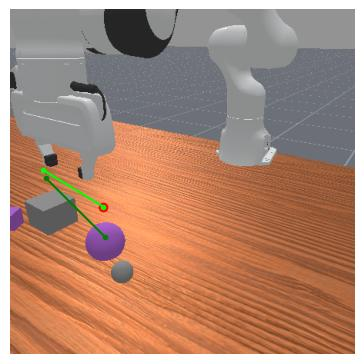
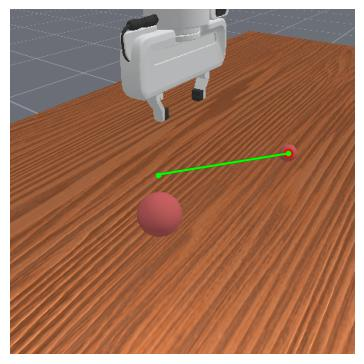
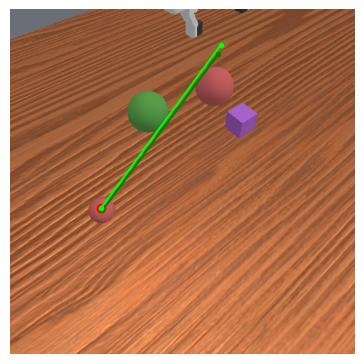
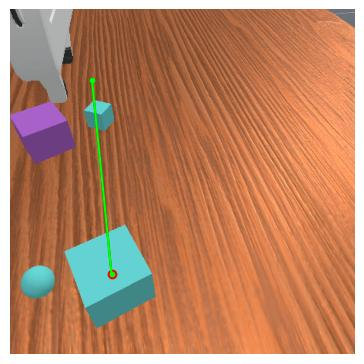
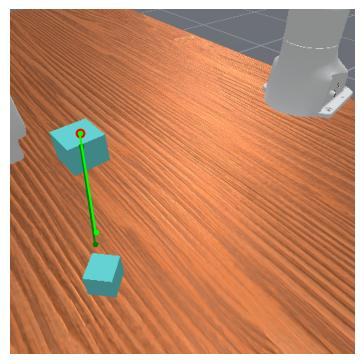
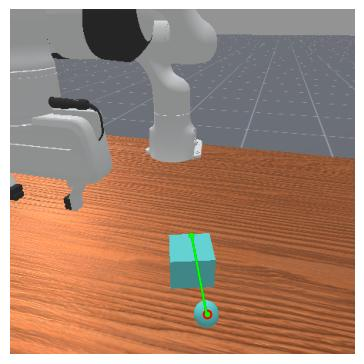
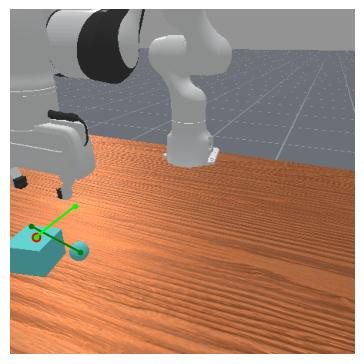
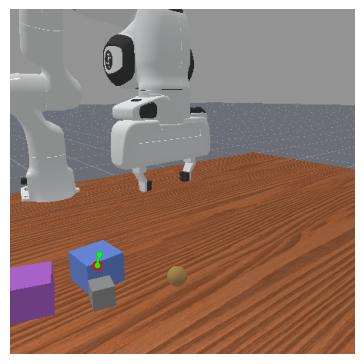
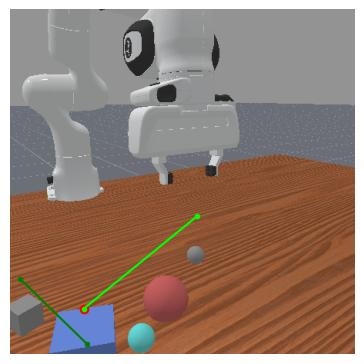
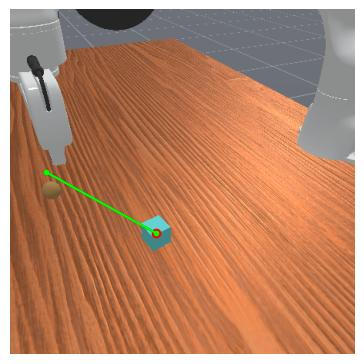
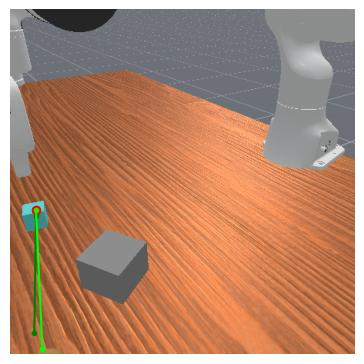
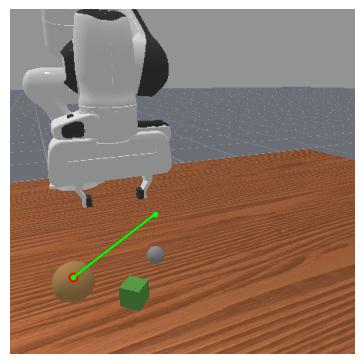
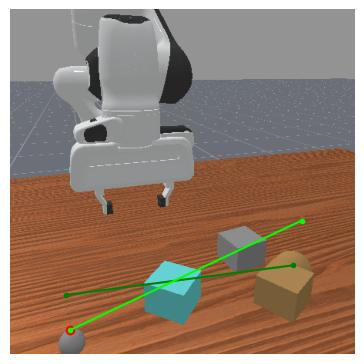
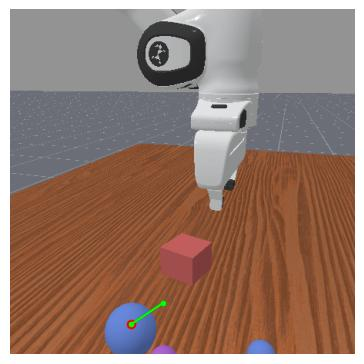
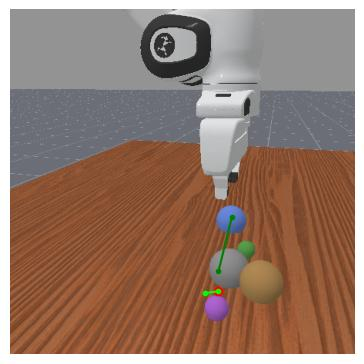
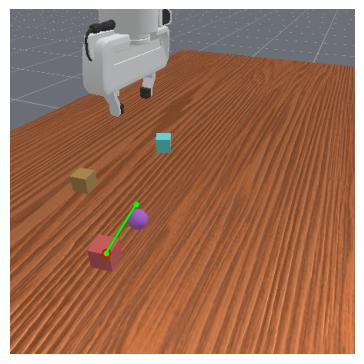
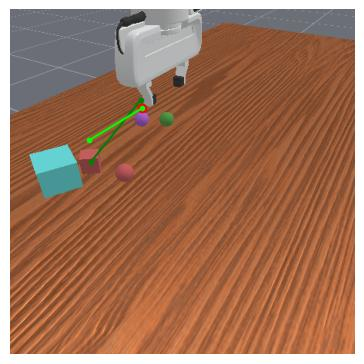
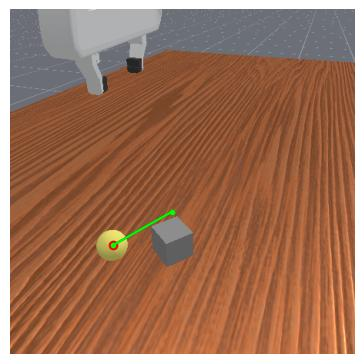
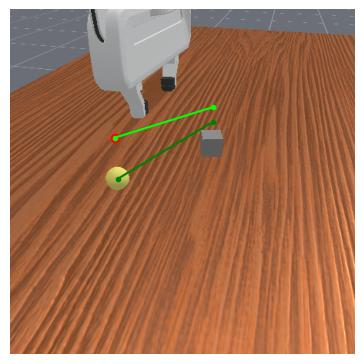
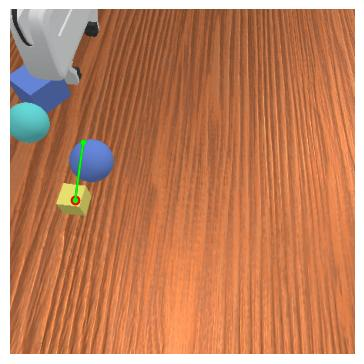
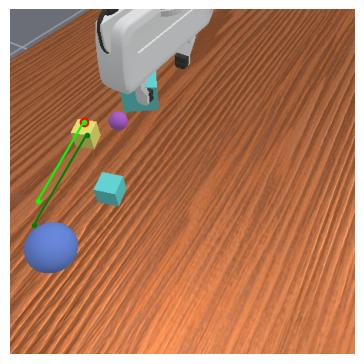
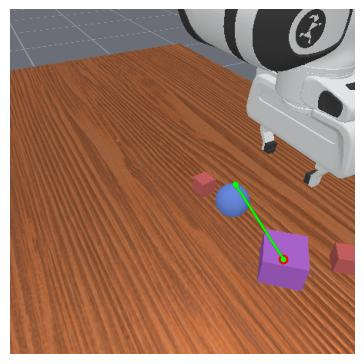
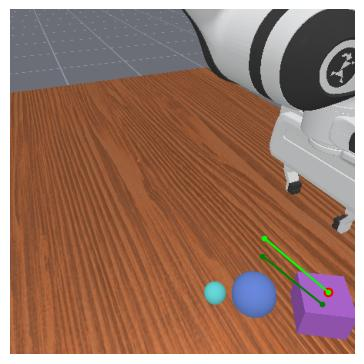
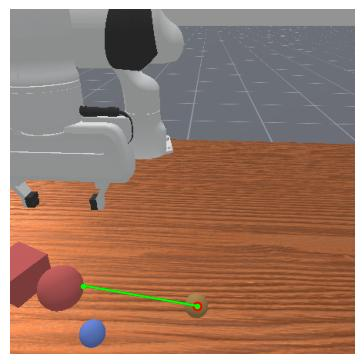
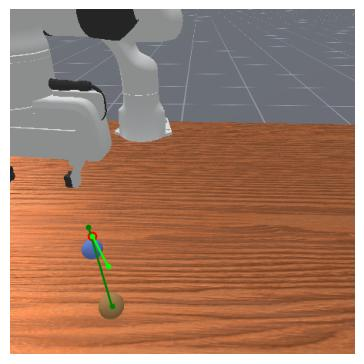
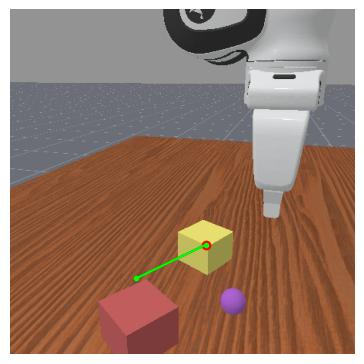
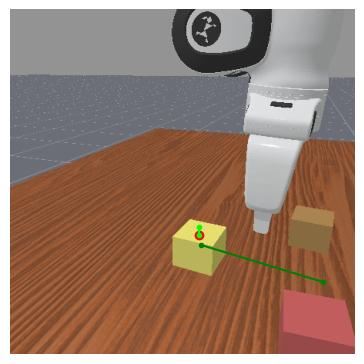
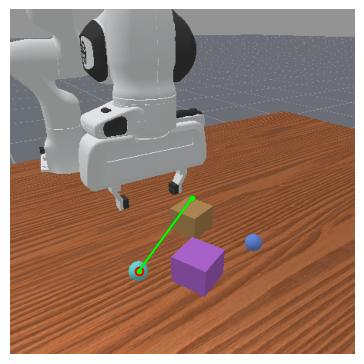
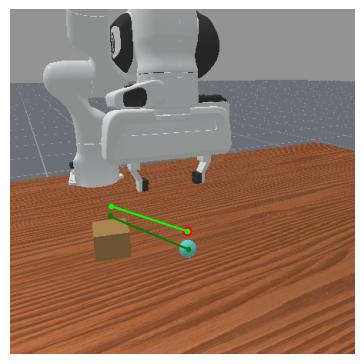
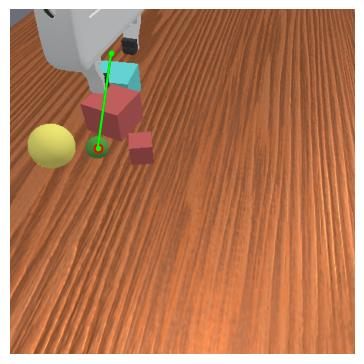
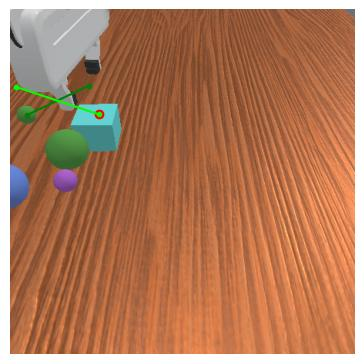
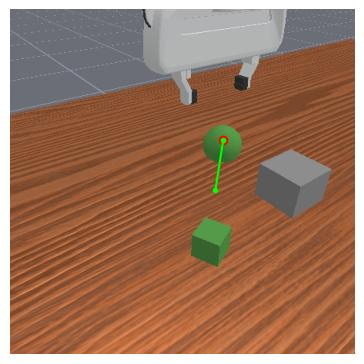
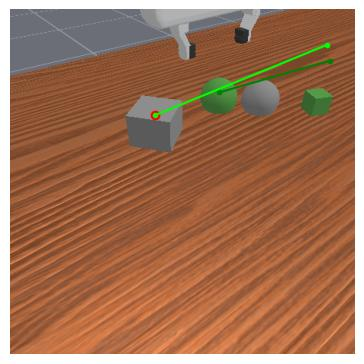
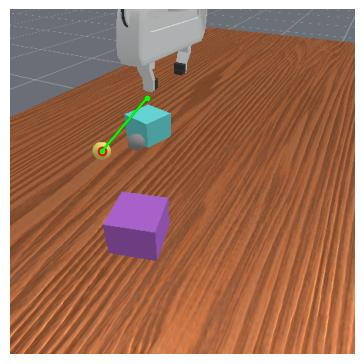
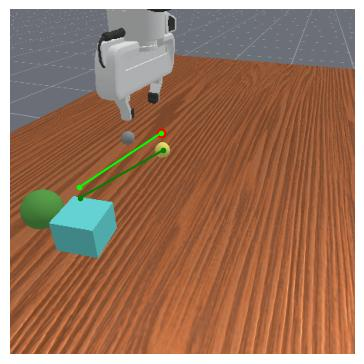
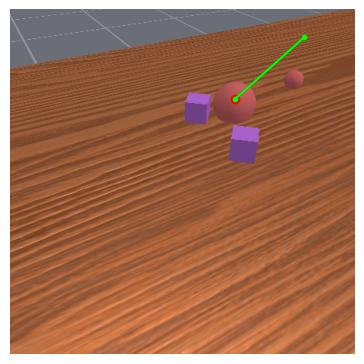
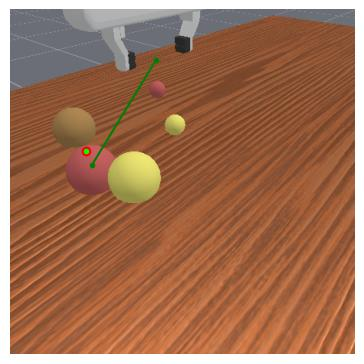
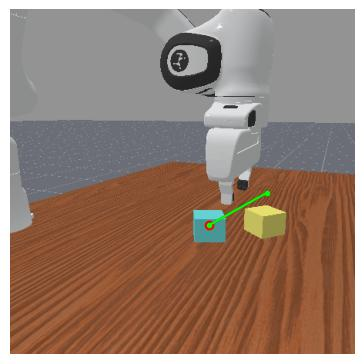
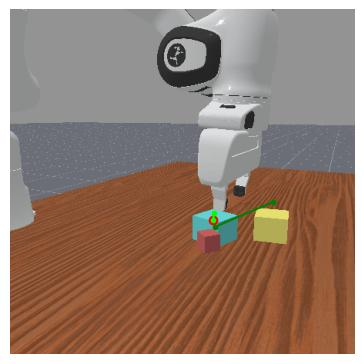
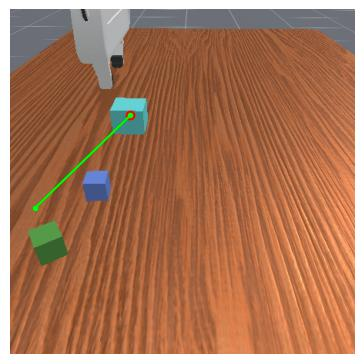
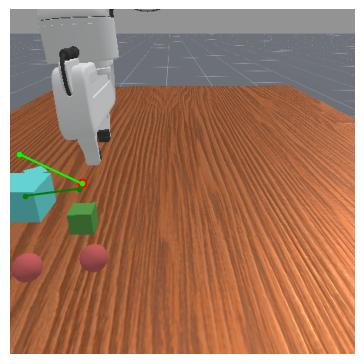
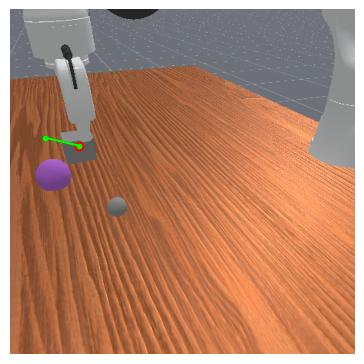
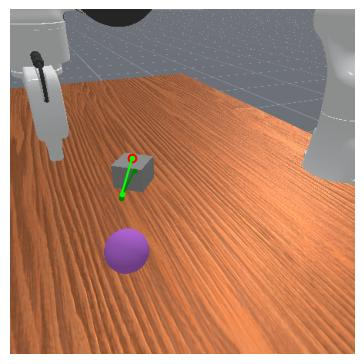
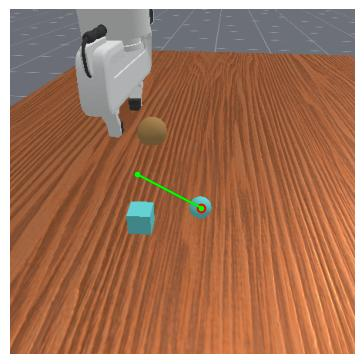
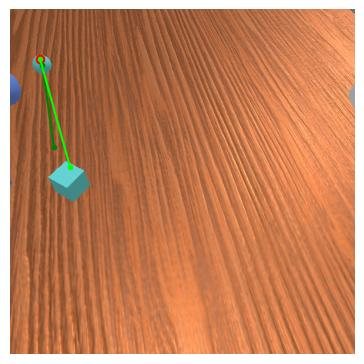
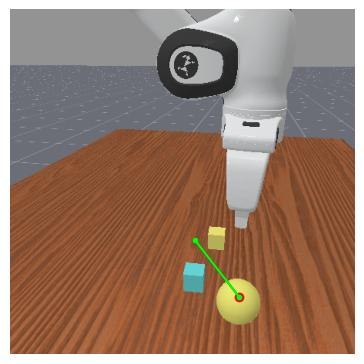
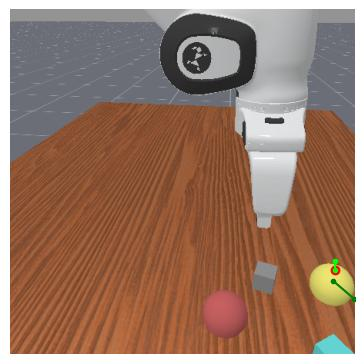
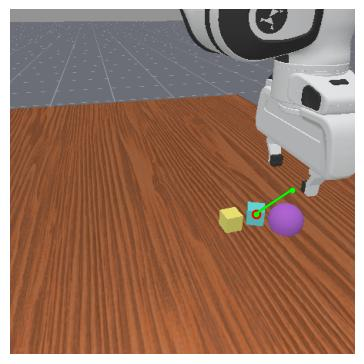
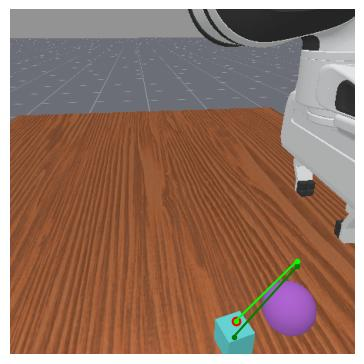
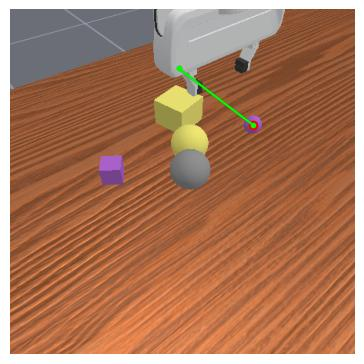
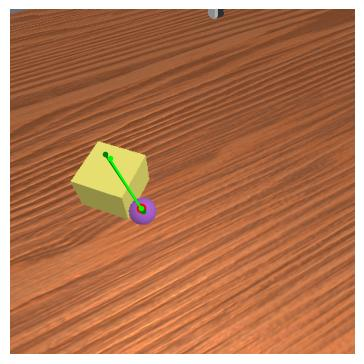
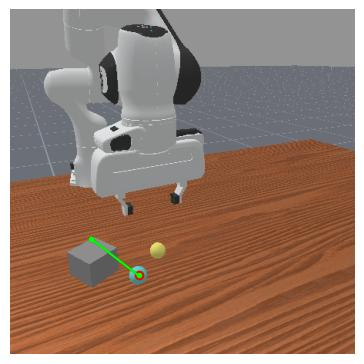
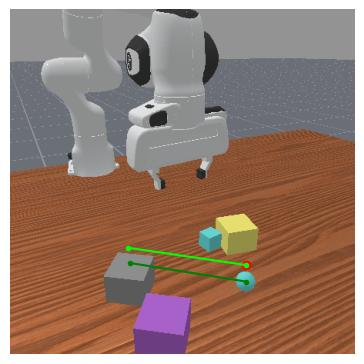
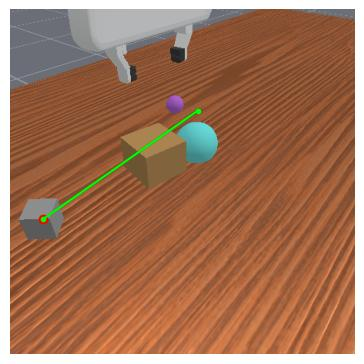
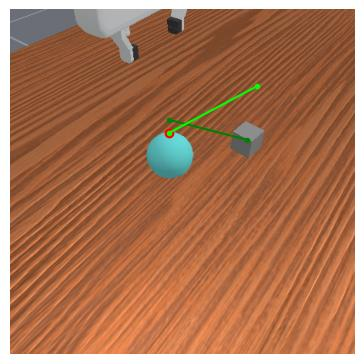
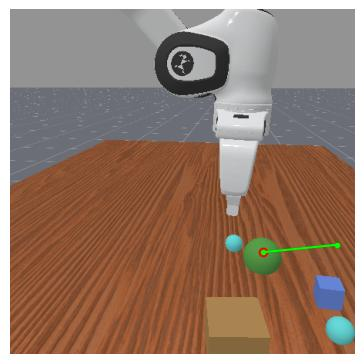
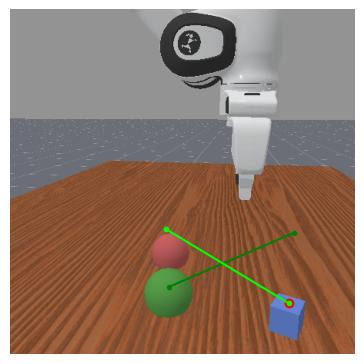
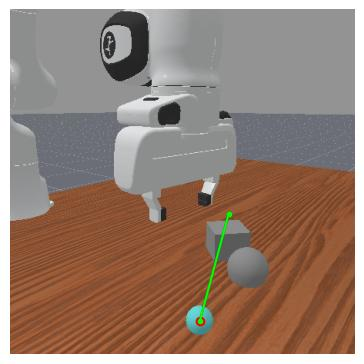
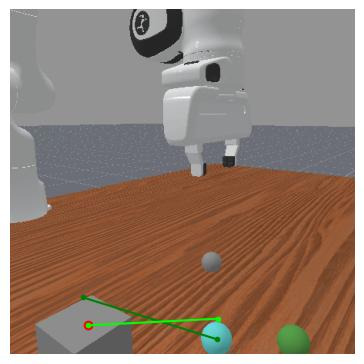
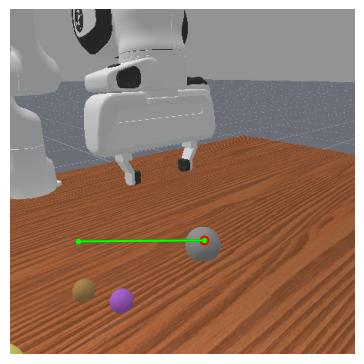
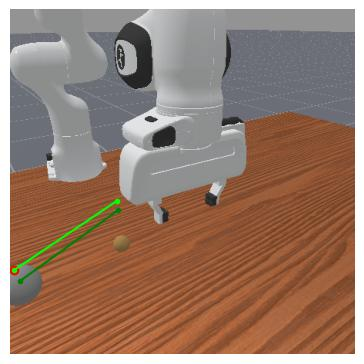
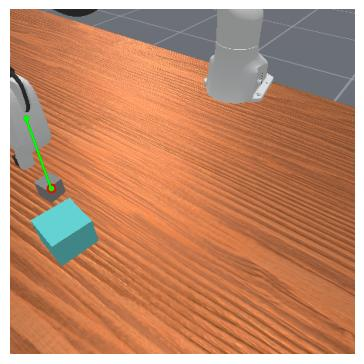
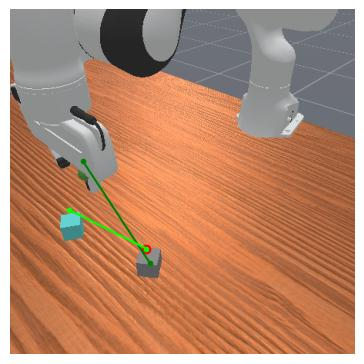
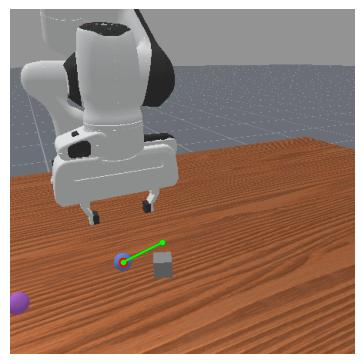
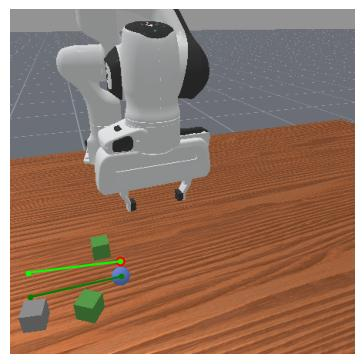
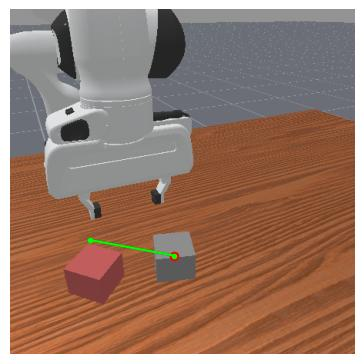
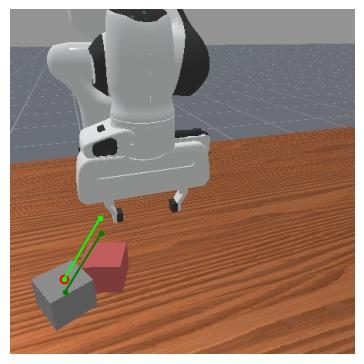
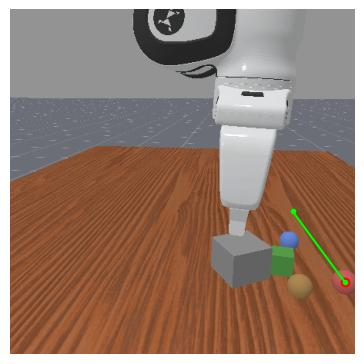
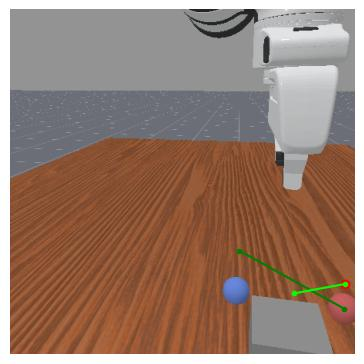
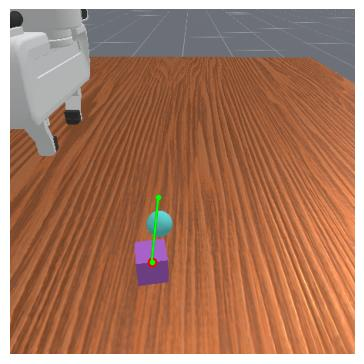
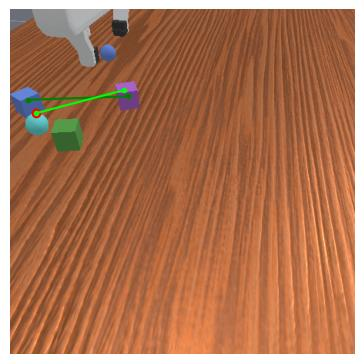
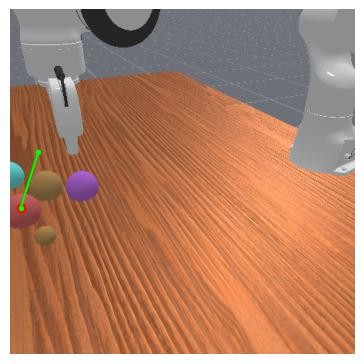
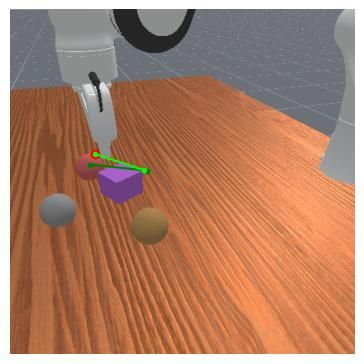
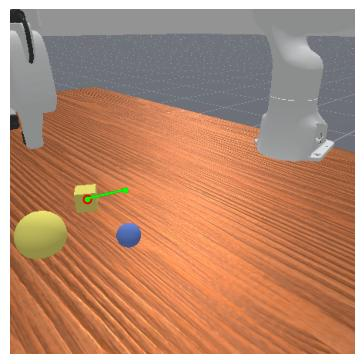
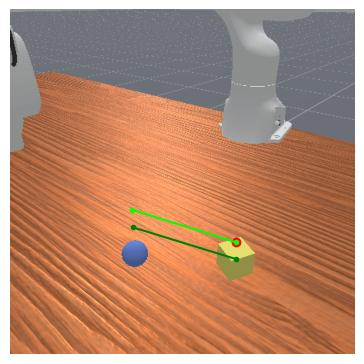
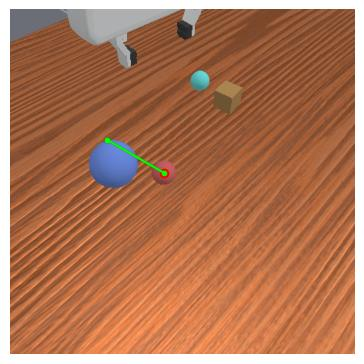
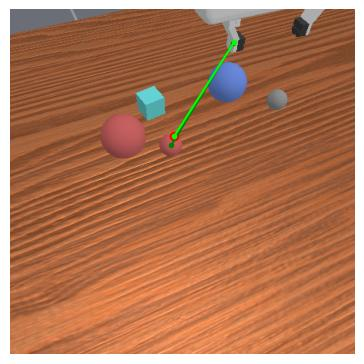
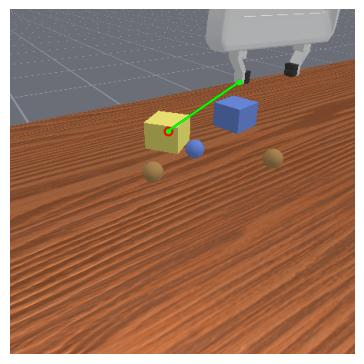
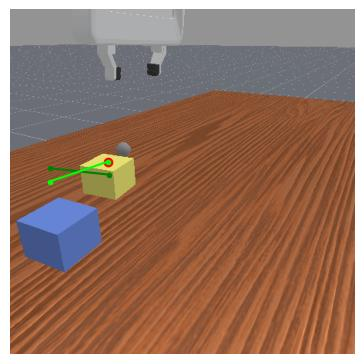
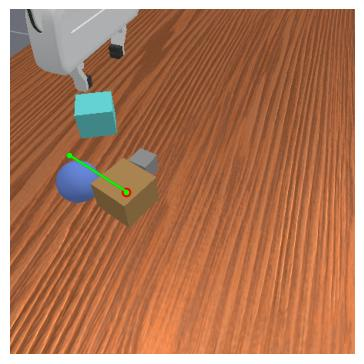
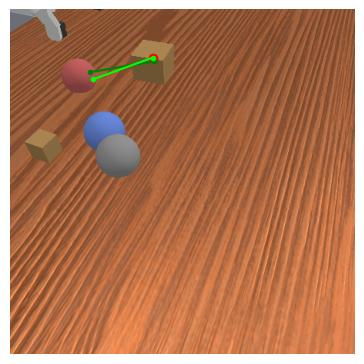
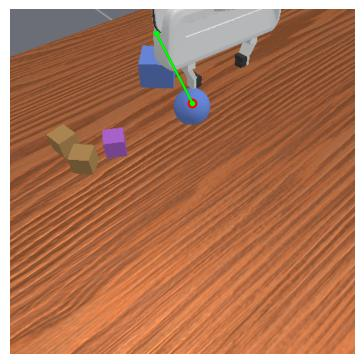
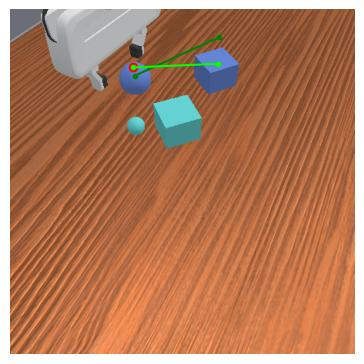
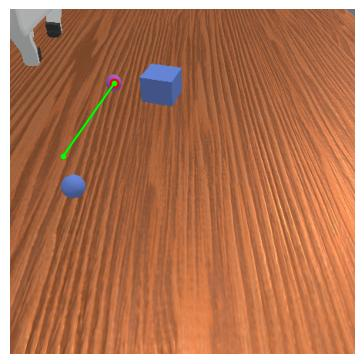
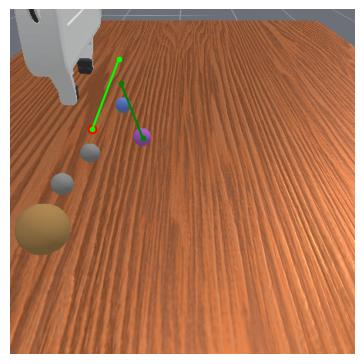
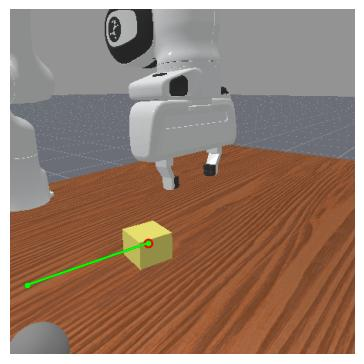
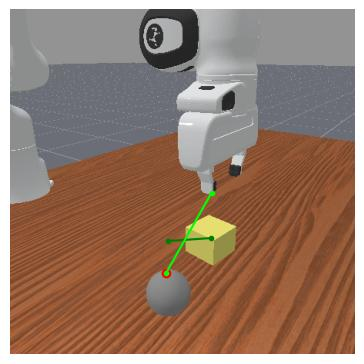
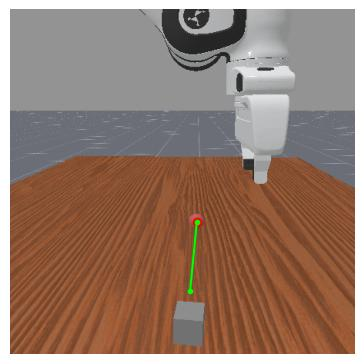
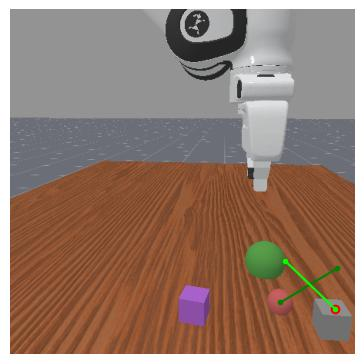
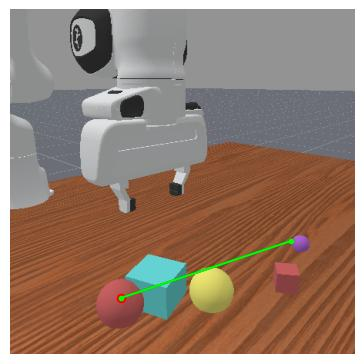
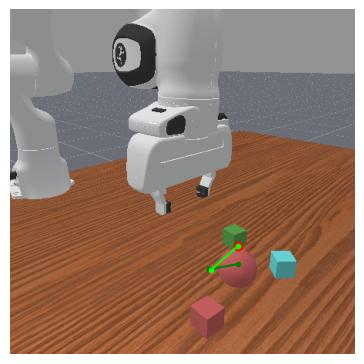
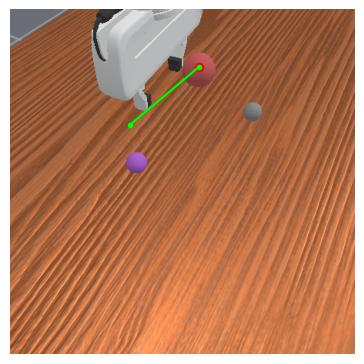
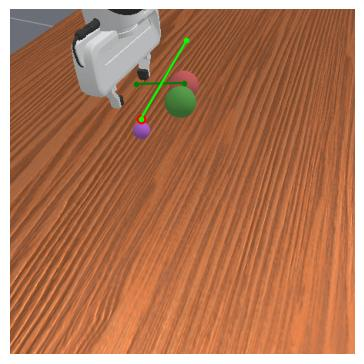
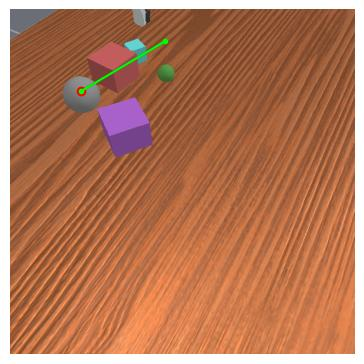
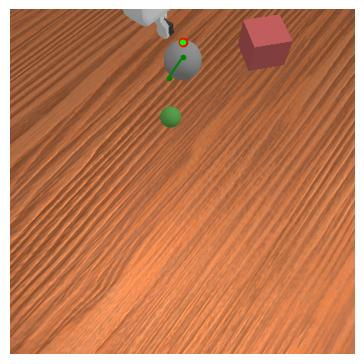
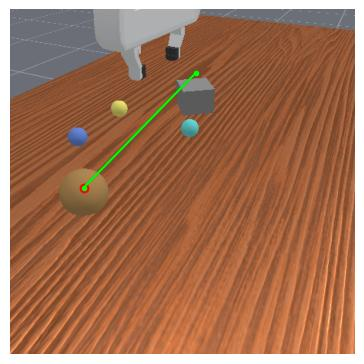
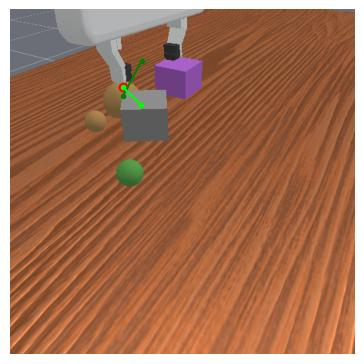
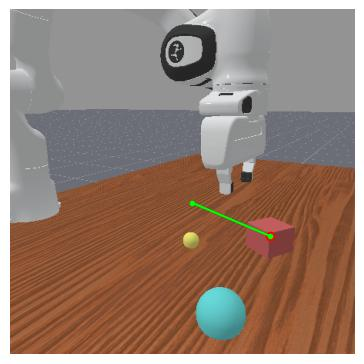
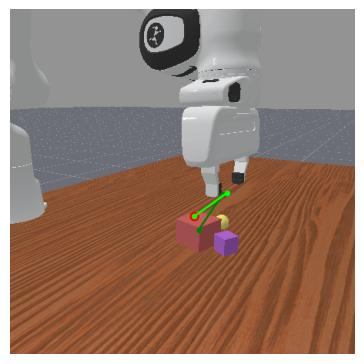
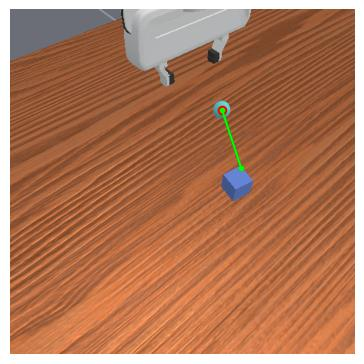
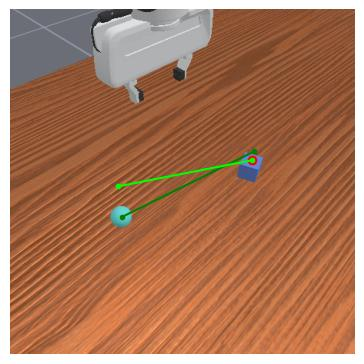

done
HTML file saved for CLEVR.


In [11]:
eval_batch_size = 8
test_samples = 80
pred_list = []
#html_imgs = ""
html_imgs = "<table style='width:100%; border-collapse: collapse;'>"


for start_idx in tqdm(range(0, test_samples, eval_batch_size), total=ceil(test_samples / eval_batch_size)):
    batch = [train_dataset[i] for i in range(start_idx, min(start_idx + eval_batch_size, test_samples))]
    inputs = collate_fn(batch)
    prefix_length = inputs["input_ids"].shape[-1]    
    decoded = []

    with torch.inference_mode():
        generation = model.generate(**inputs, max_new_tokens=max_tokens, do_sample=False, use_cache=False)
        # show only those images whose suffix is 12 tokens
        good_generation = generation[:, prefix_length:].shape[-1] == max_tokens
        for i in range(len(generation)):
            #print(inputs["input_ids"][i].shape, generation[i].shape, # processor.decode(generation[i], skip_special_tokens=False), 
            #      "Tokens after prefix length: ",processor.decode(generation[i, prefix_length:], skip_special_tokens=False) )
            #if generation[i, prefix_length:].shape[-1] != max_tokens:
            #    decoded.append("")
            #else:
            decoded.append(processor.decode(generation[i, prefix_length:], skip_special_tokens=True))
        
        # decoded = [processor.decode(x, skip_special_tokens=True) for x in generation[:, prefix_length:]]
    pred_list.extend(decoded)
    
    for batch_entry, decoded_str in zip(batch, decoded):
       
        if return_depth:
            (depth, image), sample = batch_entry
        else:
            images, samples = batch_entry

        #if decoded_str == "":
        #    continue
        html_img = render_example(images[0], text=samples[0]["prefix"], label=samples[0]["suffix"], prediction=samples[0]["suffix"], camera=sample["camera"], 
                                  action_encoder_data=action_encoder, action_encoder_model=action_encoder)
        # html_imgs += html_img
        html_query = render_example(images[1], text=samples[1]["prefix"], label=samples[1]["suffix"], prediction=decoded_str, camera=sample["camera"], 
                                    action_encoder_data=action_encoder, action_encoder_model=action_encoder)
        # html_imgs += html_query
        # html_imgs += "\n"

        html_imgs += "<tr>"
        html_imgs += f"<td style='width:33%; '>{html_img}</td>"
        html_imgs += f"<td style='width:33%; '>{html_query}</td>"
        html_imgs += "</tr>"

html_imgs += "</table>"
plot_images = True
if plot_images:
    from IPython.display import display, HTML
    display(HTML(html_imgs))

print("done")

# Save the HTML to a file after generating it
with open(html_save_file_train, "w") as f:
    f.write(html_imgs)
print("HTML file saved for CLEVR.")